# **Suboptimal Minima Stability Study**

## **Step No. 1 - Importing from Libraries and Previous Experiments**


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
from numpy.linalg import pinv

import random
import copy
from copy import deepcopy

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
import statistics

import io
from PIL import Image
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import itertools

> **Global / General Use Functions**
>* I’m bringing my **SLS code** from **Experiment #1** so I can verify whether the dataset is Sequentially Linearly Separable (SLS).
> * I am also bringing code to **plot truncation maps** from **Experiment #2.**
> * I am also bringing code to convert cumulative -> layerwise from **(CE24 Eq. (5)-(6))**



In [ ]:
def run_sls_analysis(x_train_flat, y_train_subset, selected_digits, strict_threshold=0.04):
    print("\n----------- STRICT SLS TEST RESULTS -----------\n")
    class_means = {}
    for label in np.unique(y_train_subset):
        class_images = x_train_flat[y_train_subset == label]
        mean_vector = np.mean(class_images, axis=0)
        class_means[label] = mean_vector

    means_stack = np.stack([class_means[cls] for cls in selected_digits])
    barycenter = np.mean(means_stack, axis=0)

    def sls_experiment(strict=True, error_threshold=strict_threshold):
        x_mod = x_train_flat.copy()
        y_mod = y_train_subset.copy()

        separation_results = {}
        misclassified_counts = {}
        class_means_copy = class_means.copy()
        pn_points = {}
        error_rate_dict = {}

        for n in selected_digits:
            if len(np.unique(y_mod)) == 1:
              separation_results[n] = True
              misclassified_counts[n] = 0
              error_rate_dict[n] = 0
              if strict:
                  print(f"Class {n} Separation Error Rate: 0% - Only Class Left")
              continue

            y_binary = np.where(y_mod == n, 1, -1)
            clf = LinearSVC(C=1.0, max_iter=10000)
            clf.fit(x_mod, y_binary)

            preds = clf.predict(x_mod)
            error_rate = np.mean(preds[y_binary == 1] != 1)

            is_perfect = error_rate == 0.0
            separation_results[n] = is_perfect
            misclassified_counts[n] = np.sum(preds != y_binary)
            error_rate_dict[n] = error_rate

            if strict:
                print(f"Class {n} Separation Error Rate: {error_rate*100:.2f}%")

            if not is_perfect and (strict or error_rate > error_threshold):
                break

            w = clf.coef_[0]
            b = clf.intercept_[0]
            direction = barycenter - class_means_copy[n]
            t = -(np.dot(w, class_means_copy[n]) + b) / np.dot(w, direction)
            p_n = class_means_copy[n] + t * direction
            pn_points[n] = p_n

            x_mod[y_mod == n] = p_n
            keep_mask = y_mod != n
            x_mod = x_mod[keep_mask]
            y_mod = y_mod[keep_mask]

        return separation_results, misclassified_counts, error_rate_dict, error_threshold, pn_points

    results_strict, errors_strict, error_rate_dict_strict, _, _ = sls_experiment(strict=True)
    results_relaxed, errors_relaxed, error_rate_dict_relaxed, error_threshold, pn_points = sls_experiment(strict=False)

    if all(results_strict.values()):
        print("\n- ✅ DATASET IS SLS UNDER STRICT CONDITIONS.")
    else:
        print("\n❌ Dataset is NOT SLS under strict conditions.")

    processed_classes_strict = list(error_rate_dict_strict.keys())
    processed_classes_relaxed = list(error_rate_dict_relaxed.keys())
    errors_strict_pct = [error_rate_dict_strict[d] * 100 for d in processed_classes_strict]
    errors_relaxed_pct = [error_rate_dict_relaxed[d] * 100 for d in processed_classes_relaxed]
    error_threshold_pct = error_threshold * 100

#-------------------------------------------------------------------------------------------------------------------------------------------

def plot_truncated(Ws, bs, X_train, y_train):
    L = len(Ws)
    L1 = len(bs)

    W_cum_chain = []
    b_cum_chain = []

    for ell in range(L):
        if ell == 0:
            Wcum = Ws[0]
            bcum = bs[0]
        else:
            Wcum = Ws[ell] @ W_cum_chain[-1]
            btemp = 0
            for k in range(ell):
                chain = Ws[ell]
                for j in range(ell-1, k, -1):
                    chain = chain @ Ws[j]
                btemp += chain @ bs[k]
            bcum = btemp + bs[ell]

        W_cum_chain.append(Wcum)
        b_cum_chain.append(bcum)

    # Compute Truncated Data (Using Truncation Map Definition)
    X_trunc_chain = [X_train]


    for ell in range(L-1):
        Wcum = W_cum_chain[ell]
        bcum = b_cum_chain[ell]

        W_pinv = np.linalg.pinv(Wcum)
        Z = X_trunc_chain[ell] @ Wcum.T + bcum # WARNING: This is wrong. (10/11 - Don't know why this is here?)
        Z_relu = np.maximum(Z, 0)

        X_trunc = (W_pinv @ (Z_relu.T - bcum[:, np.newaxis])).T
        X_trunc_chain.append(X_trunc)

    titles = ["Original Data"] + [f"Truncated Layer {i+1}" for i in range(L-1)] + ["Final Output"]
    data_list = X_trunc_chain

    model = ExplicitReLU(Ws, bs).eval()
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        X_out = model(X_train_tensor).numpy()
    data_list.append(X_out)

    num_subplots = L + 1
    fig = plt.figure(figsize=(5 * num_subplots, 5))

    for i in range(num_subplots):
        dim = data_list[i].shape[1]
        if dim == 3:
            ax = fig.add_subplot(1, num_subplots, i + 1, projection='3d')
        else:
            ax = fig.add_subplot(1, num_subplots, i + 1)

        for c in np.unique(y_train):
            idx = y_train == c
            if dim == 3:
                ax.scatter(
                    data_list[i][idx, 0],
                    data_list[i][idx, 1],
                    data_list[i][idx, 2],
                    s=10,
                    label=f"Class {c}"
                )
                ax.set_zlabel("X3")
                ax.view_init(elev=20, azim=30)
            else:
                ax.scatter(
                    data_list[i][idx, 0],
                    data_list[i][idx, 1],
                    s=10,
                    label=f"Class {c}"
                )

        ax.set_title(titles[i])
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")
        if i == 0:
            ax.legend(loc='upper left', fontsize=8)

    plt.tight_layout()
    plt.show()

#-------------------------------------------------------------------------------------------------------------------------------------------

# Convert cumulative -> layerwise (CE24 Eq. (5)-(6))
def cumulative_to_layerwise(W_list, b_list):
    Ws, bs = [W_list[0]], [b_list[0]]
    for i in range(1, len(W_list)):
        Wi = W_list[i] @ pinv(W_list[i-1])
        bi = b_list[i] - Wi @ b_list[i-1]
        Ws.append(Wi)
        bs.append(bi)
    return Ws, bs


## **Step No. 2 - Implementing Dataset A (Q=3) from Previous Experiments**


DATA: Using 3-Class Gaussian Mixture (Dataset Type (a)) | Q = 3 | L = 4

----------- VISUALIZING THE GENERATED SYNTHETIC DATA -----------



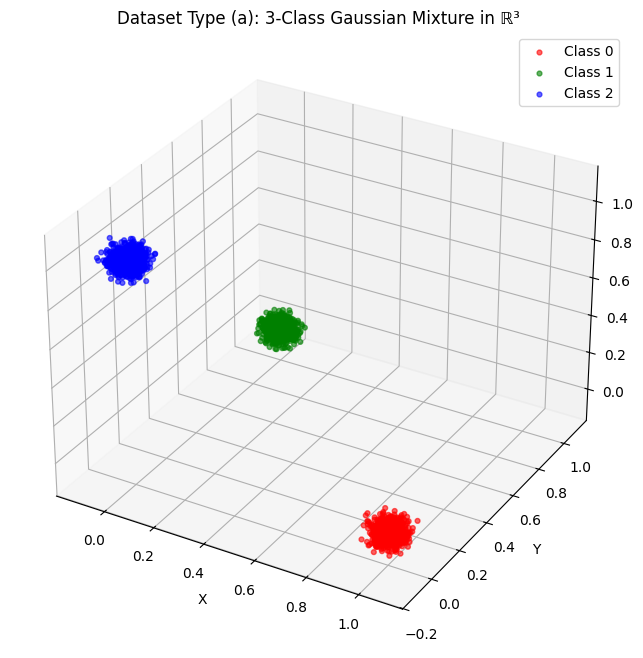

--------------------------------------------------------------------------------------

================ CONE DIAGNOSTIC CHECK ================

--- Class 0 ---
Class 0 Mean = [1.00181583e+00 3.54486240e-04 1.34482779e-03]
Centroid = [0.3329101  0.33284283 0.33425062]

Generator vectors:
  v1 = [ 0.20448133 -0.10164012 -0.10176773]
  v2 = [0. 1. 0.]
  v3 = [0. 0. 1.]

Cone axis (sum of generators):
  a_j = v1 + v2 + v3 = [0.20448133 0.89835988 0.89823227]
  ||a_j|| = 1.286734
  â_j = a_j / ||a_j|| = [0.158915   0.69817064 0.69807147]

Collapse direction:
  d_j = μ_j − centroid = [-0.66890573  0.33248834  0.33290579]
  ||d_j|| = 0.817808
  d̂_j = d_j / ||d_j|| = [-0.81792532  0.40656048  0.40707093]

Alignment check:
  cos(θ_j) = ⟨â_j , d̂_j⟩ = 0.438033
  θ_j = 1.117387 rad  (64.02°)
  ⚠️ Cone points roughly into class, but is TILTED

------------------------------------------------------

--- Class 1 ---
Class 1 Mean = [-1.70313550e-03  9.98463443e-01  1.75342227e-04]
Centroid = [0.3

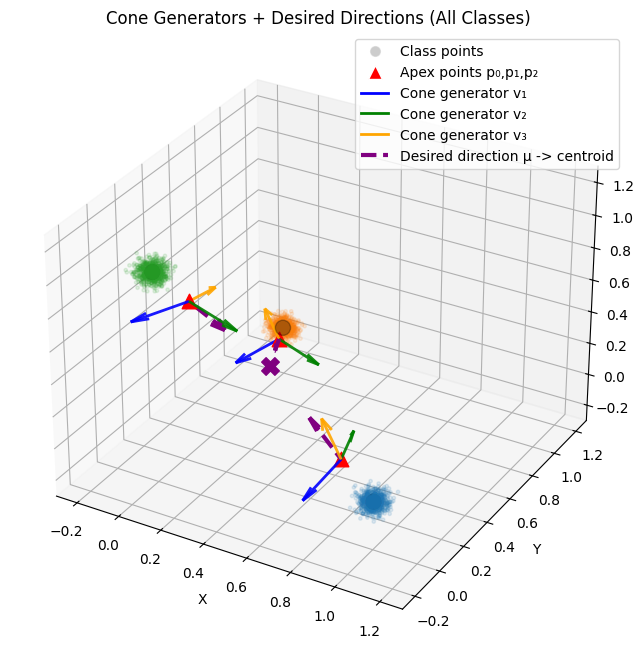

In [ ]:
def generate_gaussian_dataset_and_cone_parameters(plot=True, verbose=True):
    """
    Dataset Type (a): 3-class Gaussian mixture in R^3
    Each class is collapsed independently by one truncation cone.
    Final layer is linear regression onto one-hot labels.
    """

    # ------------------------------------------------------------------
    # Dataset parameters
    # ------------------------------------------------------------------

    selected_digits = [0, 1, 2]
    Q = len(selected_digits)
    L = Q + 1

    if verbose:
      print(f"DATA: Using 3-Class Gaussian Mixture (Dataset Type (a)) | Q = {Q} | L = {L}\n")
    dataset_info = "DATA: Using 3-Class Gaussian Mixture (Dataset Type (a))"

    # ------------------------------------------------------------------
    # Generate Gaussian mixture
    # ------------------------------------------------------------------

    X, y = make_blobs(
        n_samples=3000,
        centers=[
            [1.0, 0.0, 0.0],
            [0.0, 1.0, 0.0],
            [0.0, 0.0, 1.0]
        ],
        cluster_std=0.03,
        n_features=3,
        random_state=42
    )

    # ------------------------------------------------------------------
    # Train / test split
    # ------------------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

    # ------------------------------------------------------------------
    # Visualization
    # ------------------------------------------------------------------

    if verbose:
      print('----------- VISUALIZING THE GENERATED SYNTHETIC DATA -----------\n')

    if plot:
      fig = plt.figure(figsize=(10, 8))
      ax = fig.add_subplot(111, projection='3d')

      colors = ['r', 'g', 'b']
      for c in np.unique(y_train):
          idx = y_train == c
          ax.scatter(
              X_train[idx, 0],
              X_train[idx, 1],
              X_train[idx, 2],
              color=colors[c],
              label=f'Class {c}',
              s=12,
              alpha=0.6
          )

      ax.set_title('Dataset Type (a): 3-Class Gaussian Mixture in ℝ³')
      ax.set_xlabel('X')
      ax.set_ylabel('Y')
      ax.set_zlabel('Z')
      ax.legend()
      plt.show()

    if verbose:
      print('--------------------------------------------------------------------------------------')

    # ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Zero-loss construction (Lemma 2.1 / Type (a))
    # ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    # Compute class means
    mus = np.array([X_train[y_train == k].mean(axis=0) for k in range(Q)])

    # Separation margin
    sep = 0.25

    # CHANGES BASED ON CE24 Section 4, Page 24  ------------------ ADDITION #1 ---------------------

    # Computer Centroid
    centroid = mus.mean(axis=0)

    # Direction Vectors |  fj = (x-x0,j)/norm(x-x0,j)
    directions = []

    for k in range(Q):
        # vec = mus[k] - centroid # shouldn't it be the reverse? why is the this giving 100% accuracy
        vec = centroid - mus[k] # this doesn't seem to work, why is accuracy so low for the correct order?
        vec = vec / np.linalg.norm(vec)
        directions.append(vec)

    directions = np.array(directions)

    # Place Apex Points in front of the Class | Shift = x0,j + mu*fj
    p0 = mus[0] + sep * directions[0]
    p1 = mus[1] + sep * directions[1]
    p2 = mus[2] + sep * directions[2]

    # Standard basis
    e1 = np.array([1., 0., 0.])
    e2 = np.array([0., 1., 0.])
    e3 = np.array([0., 0., 1.])

    # ----------------------------------
    # FIRST CONE - collapse class 0
    # ----------------------------------
    V1 = np.column_stack([
        mus[0] - p0,
        e2,
        e3
    ])
    W_cum1 = pinv(V1)
    b_cum1 = -W_cum1 @ p0

    # ----------------------------------
    # SECOND CONE - collapse class 1
    # ----------------------------------
    V2 = np.column_stack([
        mus[1] - p1,
        e1,
        e3
    ])
    W_cum2 = pinv(V2)
    b_cum2 = -W_cum2 @ p1

    # ----------------------------------
    # THIRD CONE - collapse class 2
    # ----------------------------------
    V3 = np.column_stack([
        mus[2] - p2,
        e1,
        e2
    ])
    W_cum3 = pinv(V3)
    b_cum3 = -W_cum3 @ p2

    # -----------------------------------------
    # FINAL LINEAR CLASSIFIER (CE24 Theorem 6)
    # -----------------------------------------

    P = np.column_stack([p0, p1, p2])   # shape (3,3)
    Y = np.eye(3)

    W_cum4 = Y @ pinv(P)
    b_cum4 = np.zeros(3)

    W_list = [W_cum1, W_cum2, W_cum3, W_cum4]
    b_list = [b_cum1, b_cum2, b_cum3, b_cum4]

    Ws, bs = cumulative_to_layerwise(W_list, b_list)

    # ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Cone Diagnostic to Check Alignment ------------------ ADDITION #2 ---------------------
    # ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    def cone_diagnostic(Vs, mus, centroid):
        if verbose:
          print("\n================ CONE DIAGNOSTIC CHECK ================\n")

        for j, Vj in enumerate(Vs):

            if verbose:
              print(f"--- Class {j} ---")

            # Generator vectors
            v1, v2, v3 = Vj[:, 0], Vj[:, 1], Vj[:, 2]

            # Cone axis (sum of generators)
            axis_raw = v1 + v2 + v3
            axis_norm = np.linalg.norm(axis_raw)
            axis = axis_raw / axis_norm

            # Collapse direction (backward cone direction)
            #collapse_raw = mus[j] - centroid
            collapse_raw = centroid - mus[j]
            collapse_norm = np.linalg.norm(collapse_raw)
            collapse_dir = collapse_raw / collapse_norm

            # Dot product = cos(theta)
            cos_theta = np.dot(axis, collapse_dir)

            # Conversions
            cos_theta_clipped = np.clip(cos_theta, -1.0, 1.0)
            theta_rad = np.arccos(cos_theta_clipped)
            theta_deg = np.degrees(theta_rad)

            if verbose:
              # ---- PRINT EVERYTHING ----
              print(f"Class {j} Mean = {mus[j]}")
              print(f"Centroid = {centroid}\n")

              print("Generator vectors:")
              print(f"  v1 = {v1}")
              print(f"  v2 = {v2}")
              print(f"  v3 = {v3}")

              print("\nCone axis (sum of generators):")
              print(f"  a_j = v1 + v2 + v3 = {axis_raw}")
              print(f"  ||a_j|| = {axis_norm:.6f}")
              print(f"  â_j = a_j / ||a_j|| = {axis}")

              print("\nCollapse direction:")
              print(f"  d_j = μ_j − centroid = {collapse_raw}")
              print(f"  ||d_j|| = {collapse_norm:.6f}")
              print(f"  d̂_j = d_j / ||d_j|| = {collapse_dir}")

              print("\nAlignment check:")
              print(f"  cos(θ_j) = ⟨â_j , d̂_j⟩ = {cos_theta:.6f}")
              print(f"  θ_j = {theta_rad:.6f} rad  ({theta_deg:.2f}°)")

            # Interpretation
            if cos_theta < 0:
                if verbose:
                  print("  ❌ Cone points the WRONG way")
            elif cos_theta < 0.5:
                if verbose:
                  print("  ⚠️ Cone points roughly into class, but is TILTED")
            else:
                if verbose:
                  print("  ✅ Cone is well-aligned (CE24-style)")

            if verbose:
              print("\n------------------------------------------------------\n")

    cone_diagnostic([V1, V2, V3], mus, centroid)

    # ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Tilting the Cone Generators ------------------ ADDITION #3 ---------------------
    # ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    def tilt_cone_generators(Vj, mu_j, centroid, eps=0.3):

        # Current cone axis
        axis = Vj.sum(axis=1)
        axis = axis / np.linalg.norm(axis)

        # Desired collapse direction (backward cone direction)
        #desired = mu_j - centroid
        desired = centroid - mu_j
        desired = desired / np.linalg.norm(desired)

        # Difference = correction direction
        delta = desired - axis

        # Tilt all generators
        Vj_tilted = Vj + eps * delta[:, None]

        return Vj_tilted


    V1 = tilt_cone_generators(V1, mus[0], centroid, eps=0.3)
    V2 = tilt_cone_generators(V2, mus[1], centroid, eps=0.3)
    V3 = tilt_cone_generators(V3, mus[2], centroid, eps=0.3)

    W_cum1 = pinv(V1) # cone 1
    b_cum1 = -W_cum1 @ p0

    W_cum2 = pinv(V2) # cone 2
    b_cum2 = -W_cum2 @ p1

    W_cum3 = pinv(V3) # cone 3
    b_cum3 = -W_cum3 @ p2

    P = np.column_stack([p0, p1, p2])   # shape (3,3)
    Y = np.eye(3)

    W_cum4 = Y @ pinv(P) # Final Linear Classifier
    b_cum4 = np.zeros(3)

    W_list = [W_cum1, W_cum2, W_cum3, W_cum4]
    b_list = [b_cum1, b_cum2, b_cum3, b_cum4]

    Ws, bs = cumulative_to_layerwise(W_list, b_list) # Convert cumulative -> layerwise (CE24 Eq. (5)-(6))

    cone_diagnostic([V1, V2, V3], mus, centroid) # running cone diagnostic again

    # ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Geometric Visualization of all Calculations
    # ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    if plot:
      fig = plt.figure(figsize=(9, 8))
      ax = fig.add_subplot(111, projection='3d')

      scale = 0.25  # keep arrows short

      # Plot class points
      for c in np.unique(y_train):
          idx = y_train == c
          ax.scatter(
              X_train[idx, 0],
              X_train[idx, 1],
              X_train[idx, 2],
              s=6,
              alpha=0.12,
              label=f'Class {c}'
          )

      # Plot class means
      ax.scatter(
          mus[:, 0], mus[:, 1], mus[:, 2],
          color='black',
          s=120,
          marker='o',
          label='Class means μ'
      )

      # Plot centroid
      ax.scatter(
          centroid[0], centroid[1], centroid[2],
          color='purple',
          s=160,
          marker='X',
          label='Centroid'
      )

      # Per-class cones
      Vs = [V1, V2, V3]
      ps = [p0, p1, p2]

      colors = ['blue', 'green', 'orange']

      for k in range(Q):
          Vk = Vs[k]
          pk = ps[k]

          # cone generators (just plotting the contents of V1, V2, V3)
          for j in range(3):
              v = Vk[:, j]
              v = scale * v / np.linalg.norm(v)
              ax.quiver(
                  *pk, *v,
                  color=colors[j],
                  linewidth=2,
                  alpha=0.9
              )

          # desired CE24 direction (μ_k -> centroid)
          fk = centroid - mus[k]
          fk = scale * fk / np.linalg.norm(fk)
          ax.quiver(
              *pk, *fk,
              color='purple',
              linewidth=3,
              linestyle='dashed'
          )

          # apex
          ax.scatter(*pk, color='red', s=110, marker='^')

      ax.set_xlim(-0.3, 1.3)
      ax.set_ylim(-0.3, 1.3)
      ax.set_zlim(-0.3, 1.3)

      ax.set_title("Cone Generators + Desired Directions (All Classes)")
      ax.set_xlabel("X")
      ax.set_ylabel("Y")
      ax.set_zlabel("Z")

      from matplotlib.lines import Line2D

      legend_elements = [
          Line2D([0], [0], marker='o', color='w', label='Class points',
                markerfacecolor='gray', markersize=8, alpha=0.4),

          Line2D([0], [0], marker='^', color='w', label='Apex points p₀,p₁,p₂',
                markerfacecolor='red', markersize=10),

          Line2D([0], [0], color='blue', lw=2, label='Cone generator v₁'),
          Line2D([0], [0], color='green', lw=2, label='Cone generator v₂'),
          Line2D([0], [0], color='orange', lw=2, label='Cone generator v₃'),

          Line2D([0], [0], color='purple', lw=3, linestyle='--',
                label='Desired direction μ -> centroid')
      ]

      ax.legend(handles=legend_elements, loc='upper right')

      plt.show()

    meta = {
    "W_cum_list": [W_cum1, W_cum2, W_cum3],   # cone layers only
    "b_cum_list": [b_cum1, b_cum2, b_cum3],
    "p_list": [p0, p1, p2],
    "f_list": directions,                    # your unit directions fk
    "mus": mus
    }

    return Ws, bs, X_train, y_train, train_loader, dataset_info, meta


# ------------------------------------------------------------------------------------------------------------------------------------------------
_ = generate_gaussian_dataset_and_cone_parameters()

## **Step No. 3 - Building Zero Construction Loss ReLU Network**



 Construction accuracy (analytic CE24/Ewa25 initialization): 100.00%, loss=0.00000



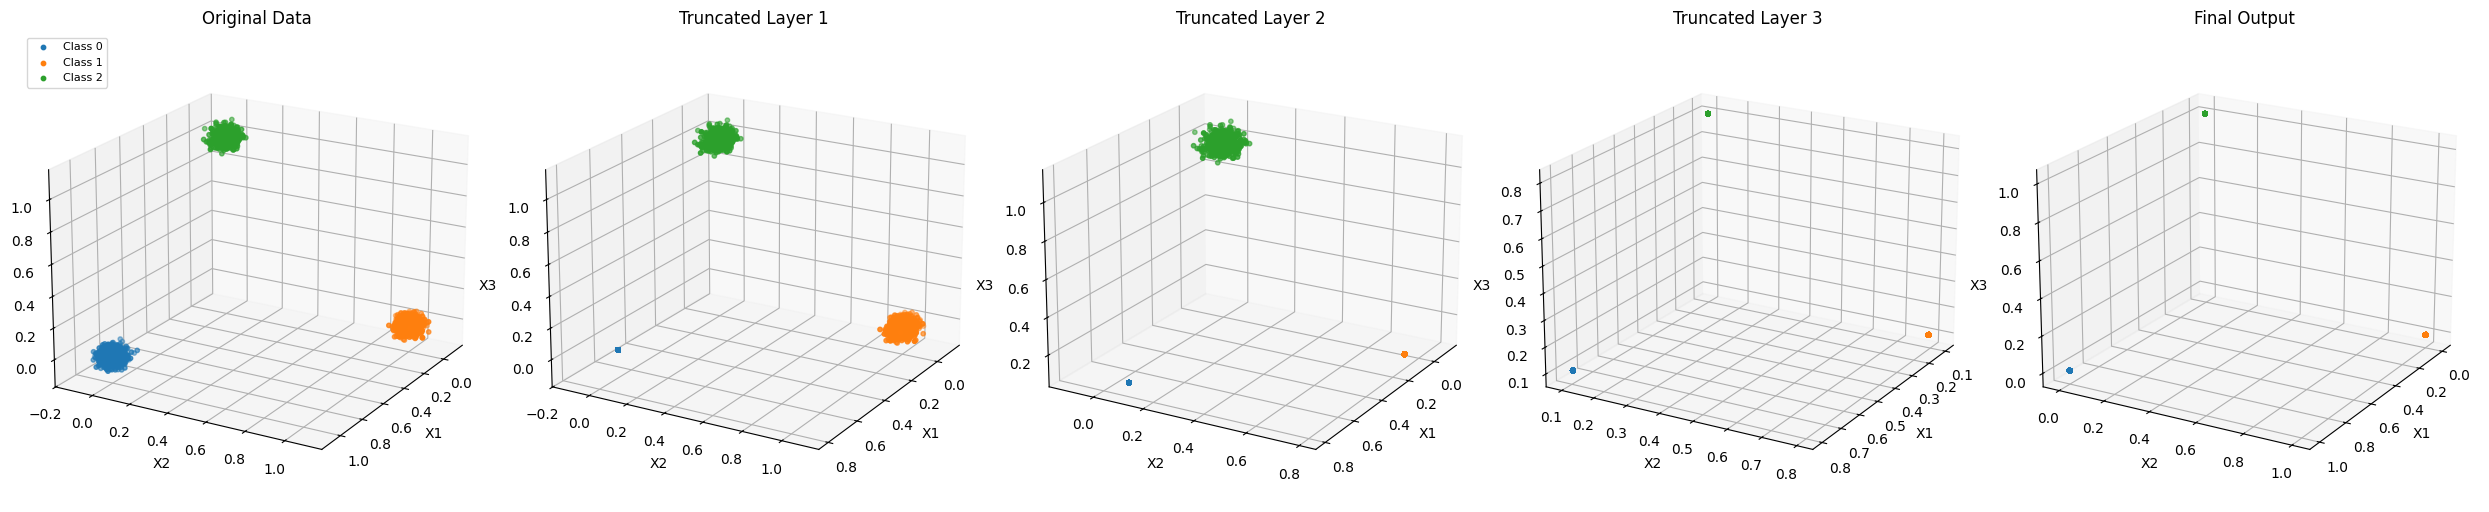

In [ ]:
# -----------------------------------------------------------------------------------------------------------
# Implements the explicit ReLU network with layerwise weights (Wₗ, bₗ) from CE24 Eq. (1) / Ewa25 Eq. (2.1)
# -----------------------------------------------------------------------------------------------------------

class ExplicitReLU(nn.Module):
    def __init__(self, Ws, bs):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(Ws[i].shape[1], Ws[i].shape[0]) for i in range(len(Ws))
        ])

        for i, l in enumerate(self.layers):
            l.weight.data = torch.tensor(Ws[i], dtype=torch.float32)
            l.bias.data   = torch.tensor(bs[i], dtype=torch.float32)

    def forward(self, x):
        # CE24/Ewa25: ReLU after each layer except the final linear layer
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        return self.layers[-1](x)

# def zero_loss_check(Ws, bs, X, y):
#     m = ExplicitReLU(Ws, bs).eval()
#     Xt = torch.tensor(X, dtype=torch.float32)
#     yt = torch.tensor(y, dtype=torch.long)
#     criterion = nn.CrossEntropyLoss()

#     with torch.no_grad():
#         out = m(Xt) *50.0 # change if needed
#         loss = criterion(out, yt)
#         acc = (out.argmax(1) == yt).float().mean().item()

def zero_loss_check(Ws, bs, X, y):
    m = ExplicitReLU(Ws, bs).eval()
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    criterion = nn.MSELoss()

    with torch.no_grad():
        out = m(Xt)          # no softmax
        yt_oh = F.one_hot(yt, num_classes=3).float()
        loss = criterion(out, yt_oh)
        acc = (out.argmax(1) == yt).float().mean().item()

    print(f"\n Construction accuracy (analytic CE24/Ewa25 initialization): {acc*100:.2f}%, loss={loss:.5f}\n")
    plot_truncated(Ws, bs, X, y)
    return m, acc

#------------- ONLY ALTER VALUES BELOW -------------
Ws, bs, X_train, y_train, _, _, meta = generate_gaussian_dataset_and_cone_parameters(plot=False, verbose=False) # Zero Loss Construction Parameters for Synthetic Dataset A
_ = zero_loss_check(Ws, bs, X_train, y_train)

## **Step No. 4a - Constructing Suboptimal Minima**

In [ ]:
def construct_suboptimal_truncation_minima(meta, Q, M=10.0):
    """
    Constructing the 2^Q - 1 suboptimal minimas for Dataset A (symmetrical dataset).

    Parameters
    ----------
    meta:
        - meta["W_cum_list"] : list of cumulative truncation matrices W_cum,k
        - meta["p_list"]     : list of ON-state apex points p_k
        - meta["f_list"]     : list of unit directions used to shift apex for a certain truncation map (class) OFF
    Q:
        Number of classes / truncation maps (non final layer)
    M:
        Large shift magnitude used to deactivate a truncation map and shift apex OFF

    Returns
    -------
    minima:
        Each entry will correspond to one suboptimal minimum and contains:
        - "mask" : binary list length-Q with 1 = ON & 0 = OFF (ex: [101])
        - "W_cum_list" : cumulative truncation matrices (unchanged)
        - "b_cum_list" : cumulative biases encoding ON/OFF truncations
        - "apex_new_list" : shifted base points (apex points)
    """

    mus = meta["mus"]

    minima = []
    # 1 means normal collapse, 0 means we move collapse point far away

    # Iterate over all non-zero ON/OFF masks
    for mask in itertools.product([0, 1], repeat=Q):
        if sum(mask) == 0:
            continue  # skip if all off (this is why 2^Q - 1)

        print("Generating Mask: ", mask)
        b_cum_list = []
        pk_new_list = []

        for k in range(Q):
            Wk = meta["W_cum_list"][k]
            pk = meta["p_list"][k]
            fk = meta["f_list"][k]

            if mask[k] == 1:
                # ON: leave apex so class k lies in the backward cone
                p_new = pk
            else:
                # OFF: shift apex far so backward cone contains no data
                p_new = pk - M * fk # PATRICIA' SUGGESTION: change + to -

            # Recalculating bias vector as base point might have changed
            b_cum_k = -Wk @ p_new
            b_cum_list.append(b_cum_k)

            # Update with new/old points
            pk_new_list.append(p_new)

        cols = []
        for k in range(Q):
            if mask[k] == 1:
                cols.append(pk_new_list[k])  # collapsed point
            else:
                cols.append(mus[k])         # class mean (still a cluster as not collapsed)

        P_mask = np.column_stack(cols)      # shape (d, Q)
        Y = np.eye(Q)

        W_cum4 = Y @ pinv(P_mask) # final affine weights
        b_cum4 = np.zeros(Q)                # bias (same convention as before)

        W_cum_all = meta["W_cum_list"] + [W_cum4]
        b_cum_all = b_cum_list + [b_cum4]

        W_list = W_cum_all
        b_list = b_cum_all

        Ws, bs = cumulative_to_layerwise(W_list, b_list) # Convert cumulative -> layerwise (CE24 Eq. (5)-(6))

        minima.append({
          "mask": list(mask),

           # FULL cumulative network (including final layer)
          "W_cum_list": W_cum_all,
          "b_cum_list": b_cum_all,

          # geometry info
          "apex_new_list": pk_new_list,

          # layerwise network (this is what you will actually use)
          "Ws": Ws,
          "bs": bs
        })

    return minima

# Zero Loss Construction Parameters for Synthetic Dataset A

Ws, bs, X_train, y_train, _, _, meta = generate_gaussian_dataset_and_cone_parameters(plot=False,verbose=False)

## **Step No. 4b - Visualizing Suboptimal Minima**

Generating Mask:  (0, 0, 1)
Generating Mask:  (0, 1, 0)
Generating Mask:  (0, 1, 1)
Generating Mask:  (1, 0, 0)
Generating Mask:  (1, 0, 1)
Generating Mask:  (1, 1, 0)
Generating Mask:  (1, 1, 1)

-------------------------------------------------------------

Mask: [0, 0, 1]

 Construction accuracy (analytic CE24/Ewa25 initialization): 100.00%, loss=0.00071



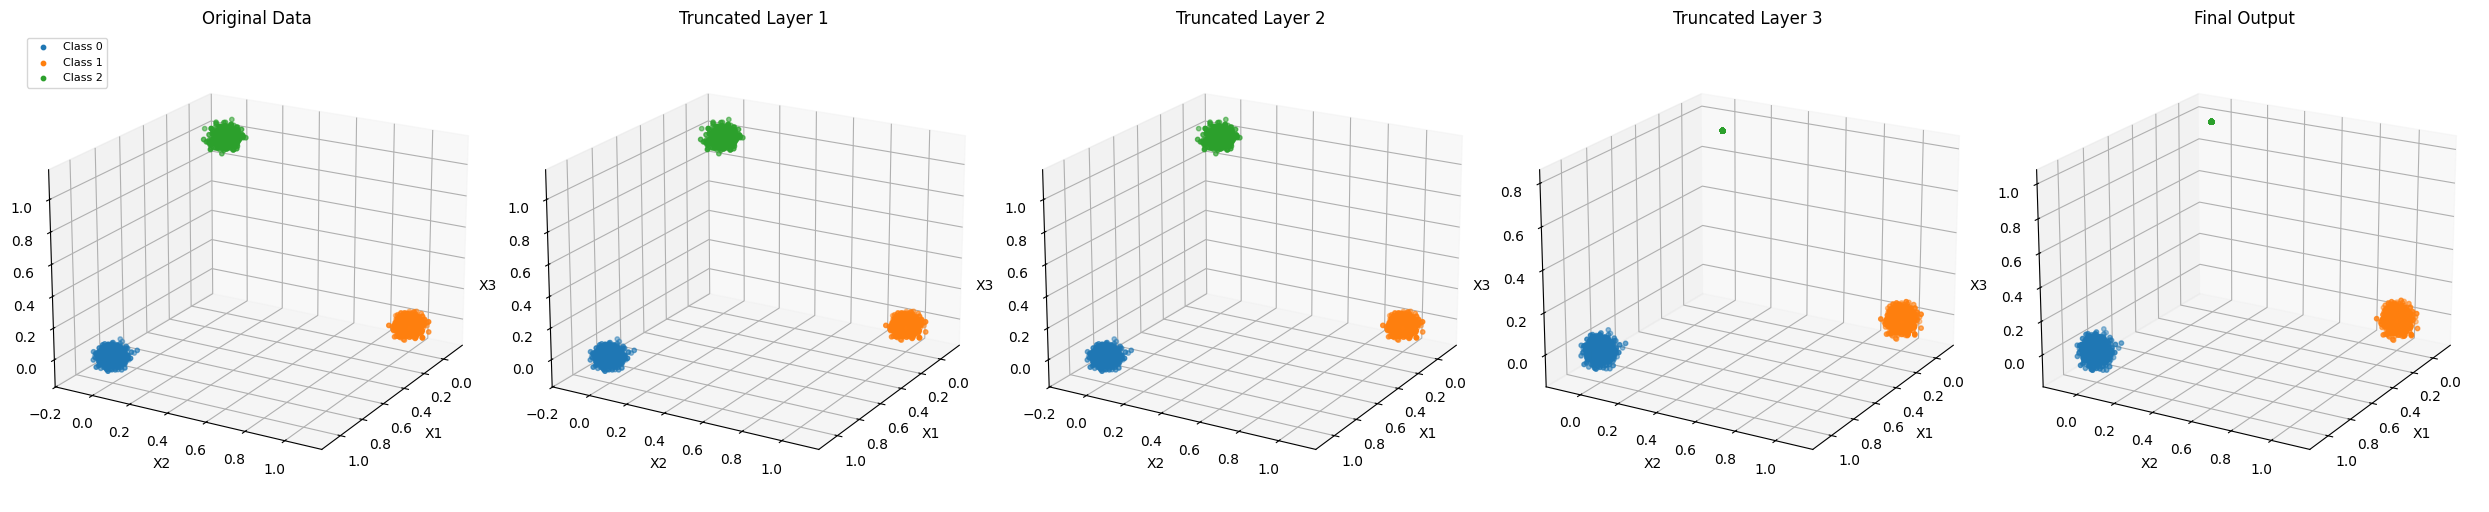


-------------------------------------------------------------

Mask: [0, 1, 0]

 Construction accuracy (analytic CE24/Ewa25 initialization): 100.00%, loss=0.00073



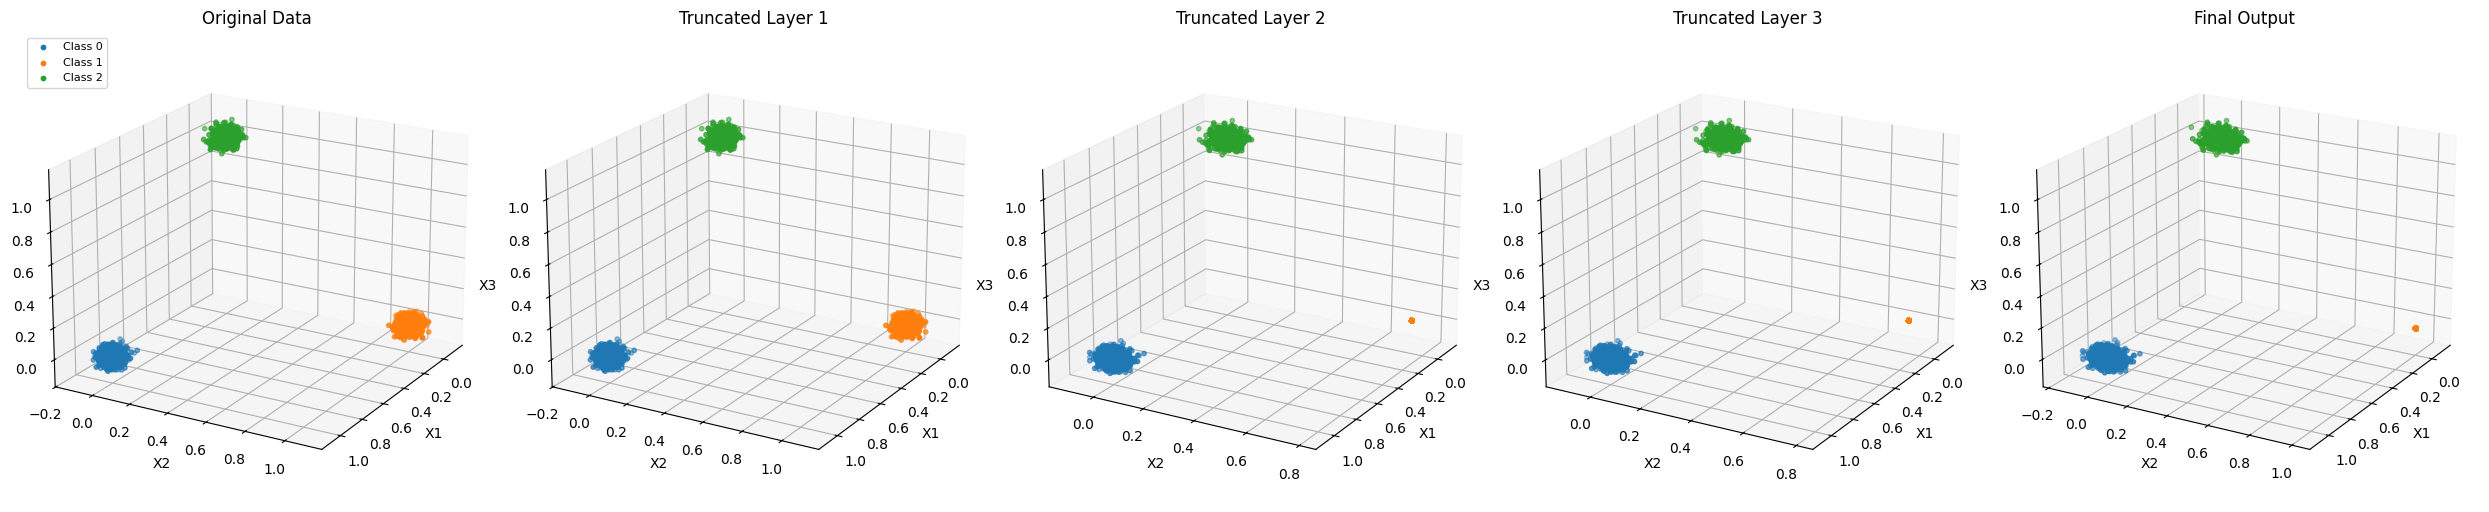


-------------------------------------------------------------

Mask: [0, 1, 1]

 Construction accuracy (analytic CE24/Ewa25 initialization): 100.00%, loss=0.00042



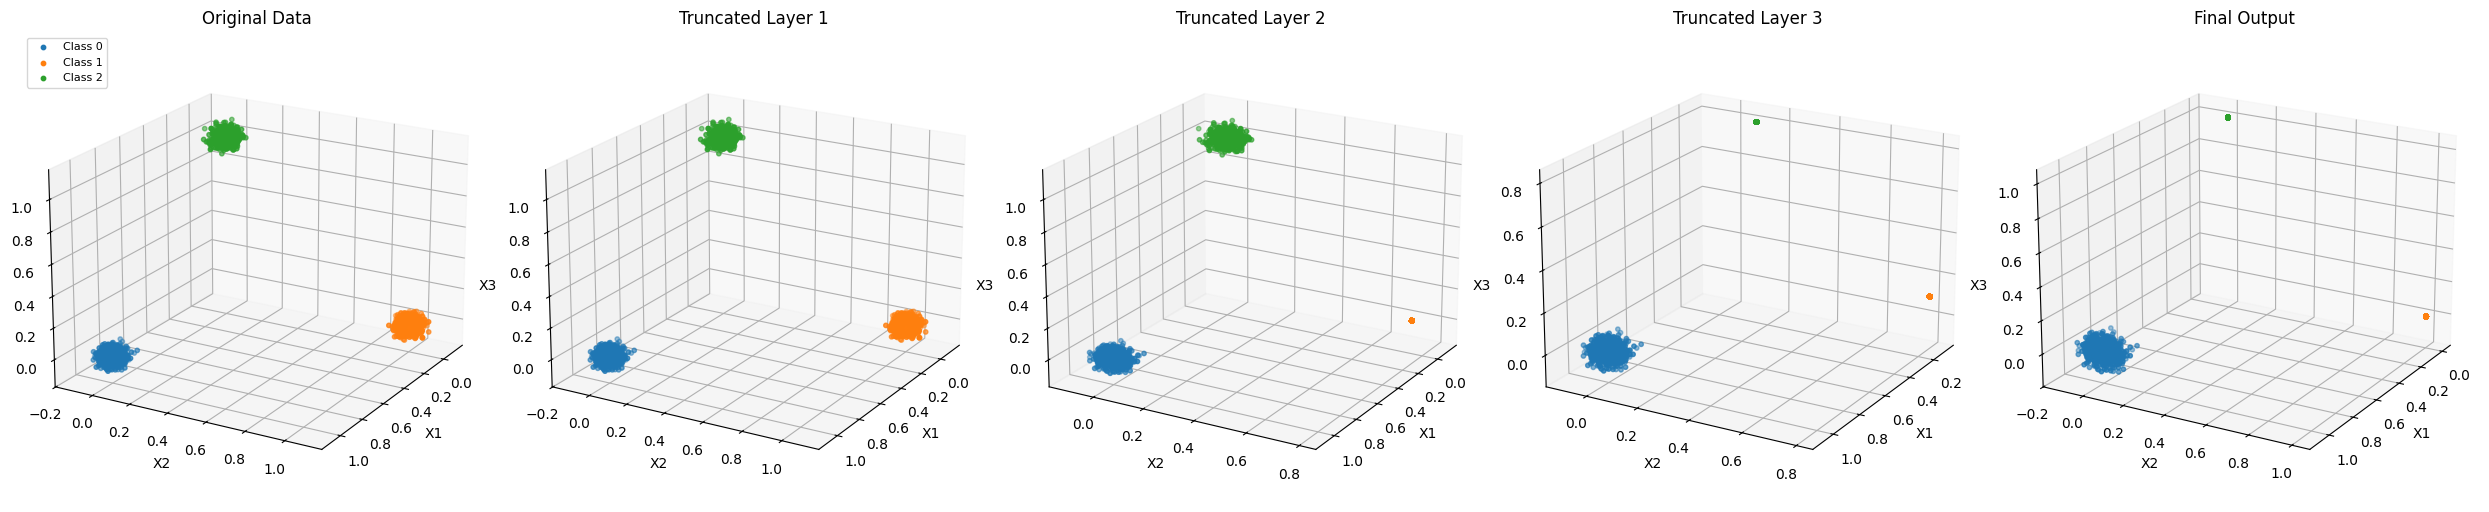


-------------------------------------------------------------

Mask: [1, 0, 0]

 Construction accuracy (analytic CE24/Ewa25 initialization): 100.00%, loss=0.00075



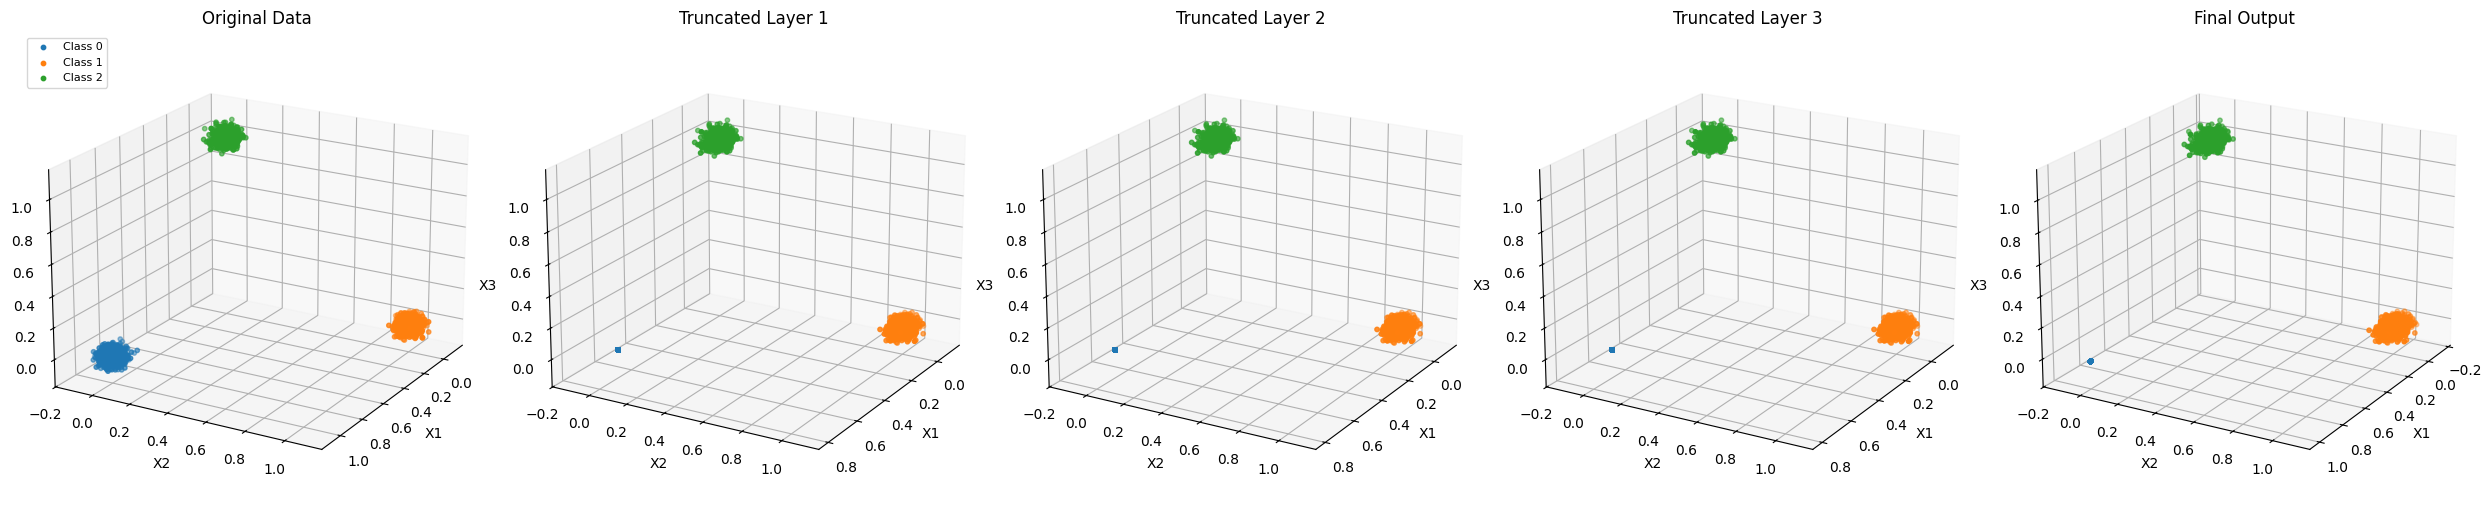


-------------------------------------------------------------

Mask: [1, 0, 1]

 Construction accuracy (analytic CE24/Ewa25 initialization): 100.00%, loss=0.00044



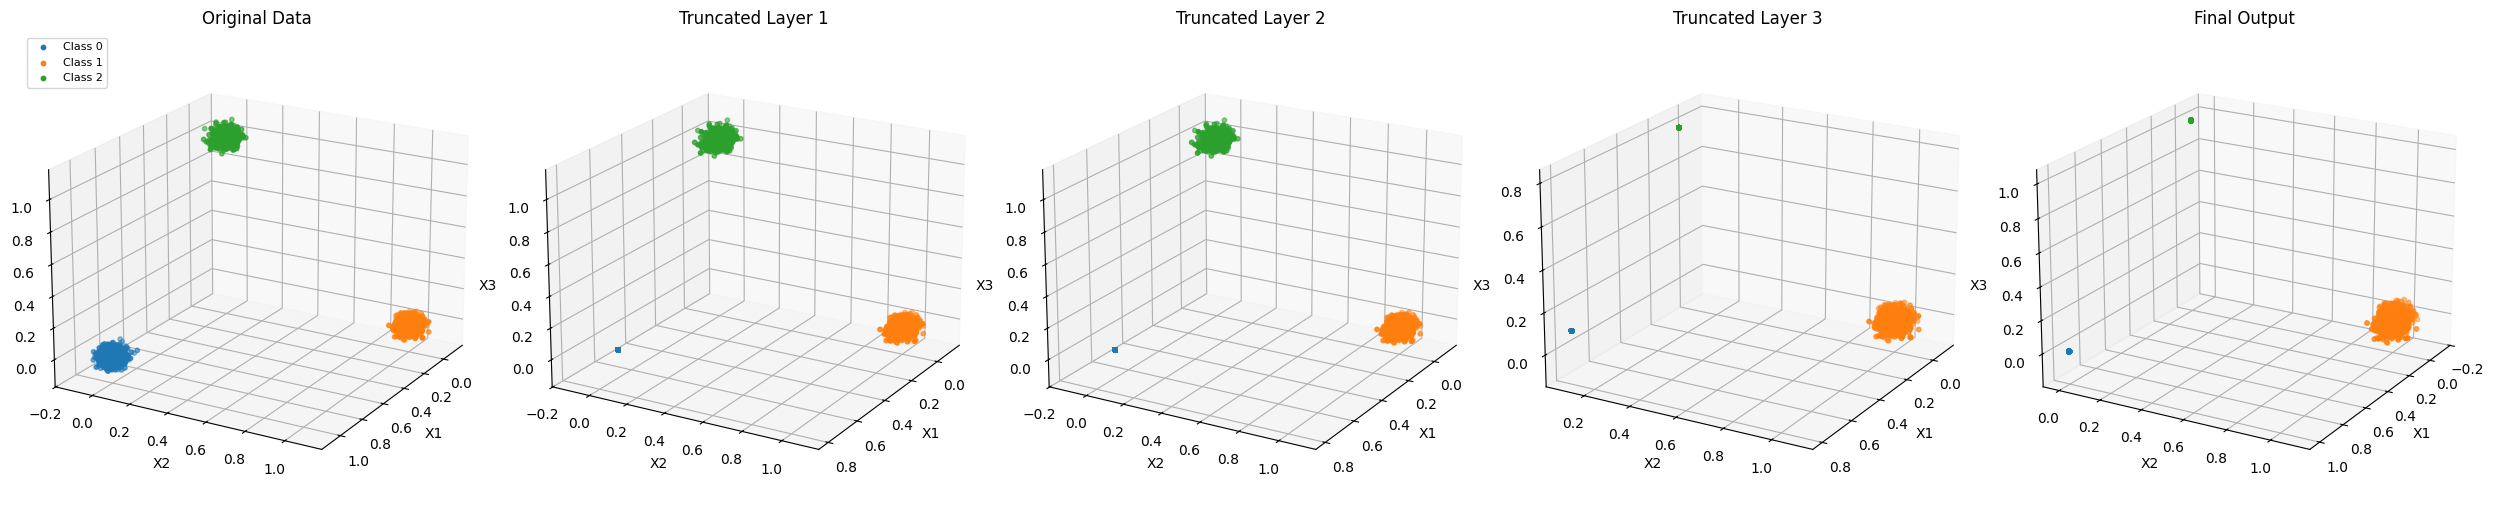


-------------------------------------------------------------

Mask: [1, 1, 0]

 Construction accuracy (analytic CE24/Ewa25 initialization): 100.00%, loss=0.00045



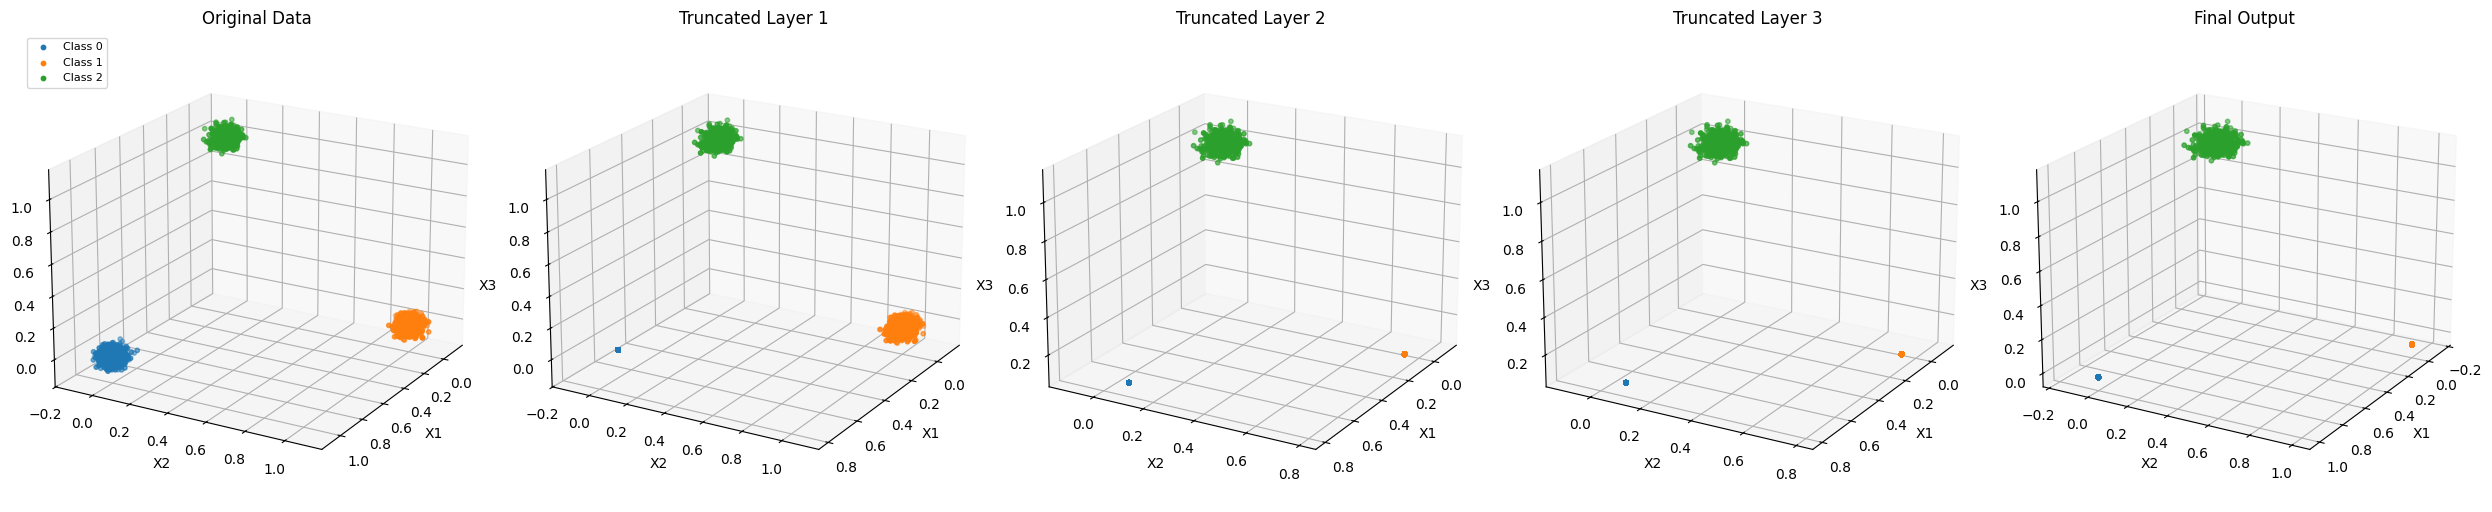


-------------------------------------------------------------

Mask: [1, 1, 1]

 Construction accuracy (analytic CE24/Ewa25 initialization): 100.00%, loss=0.00000



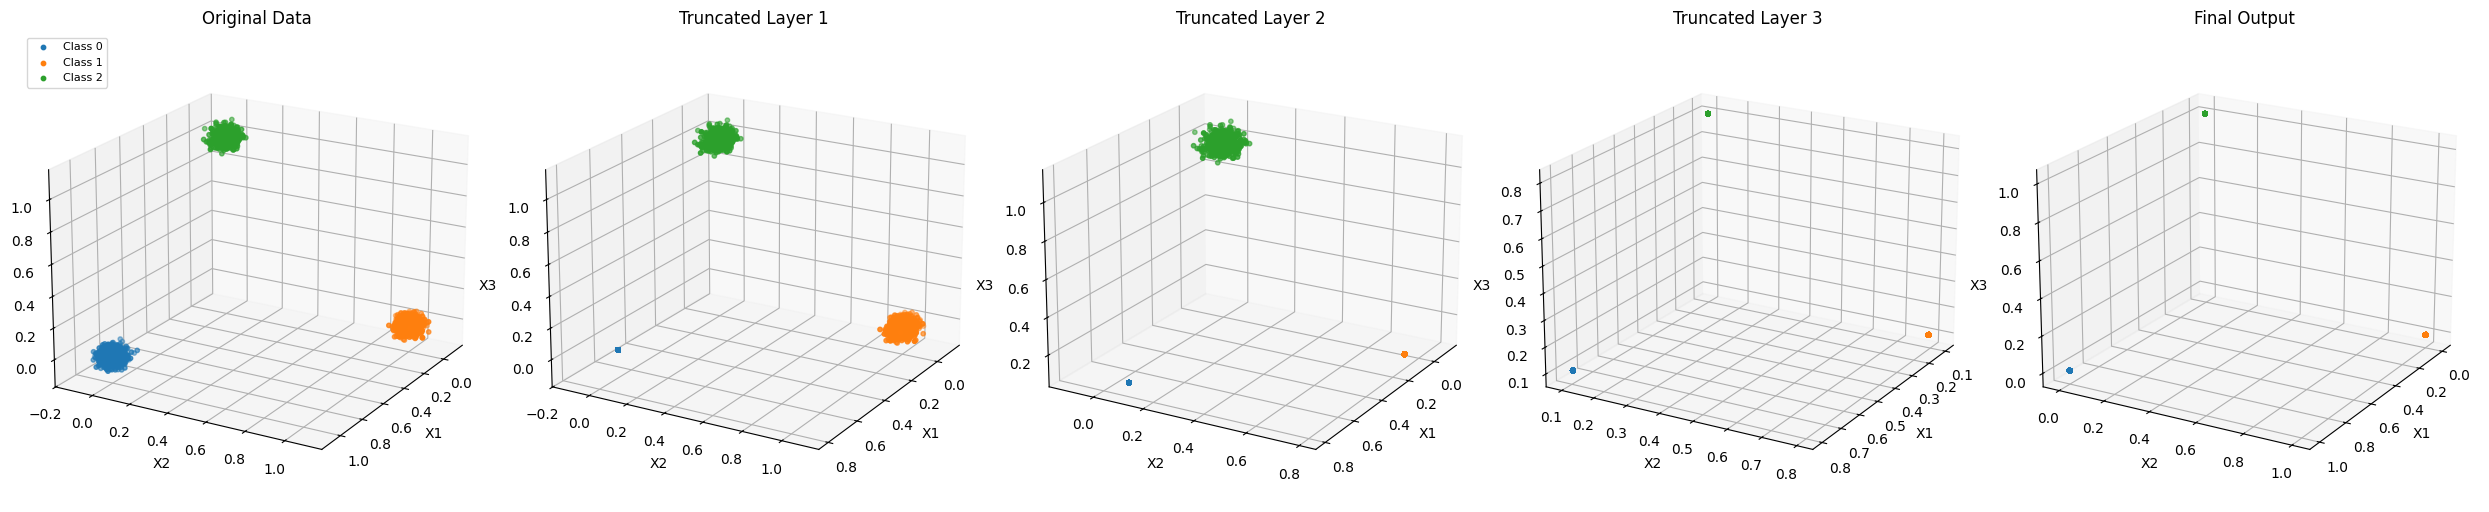


-------------------------------------------------------------



In [ ]:
minima = construct_suboptimal_truncation_minima(meta, Q=3, M=10.0) # Generating masks for 2^Q-1 Suboptimal Minima
print("\n-------------------------------------------------------------\n")
for m in minima:
    print("Mask:", m["mask"] if "mask" in m else "unknown")
    zero_loss_check(m["Ws"], m["bs"], X_train, y_train)
    print("\n-------------------------------------------------------------\n")


## **Step 5a – Creating $\lambda$ Perturbations on Suboptimal Minima to Visualize Loss Landscape**


Running λ experiment for mask: [1, 0, 0]
λ=0.0150 | loss=0.00965±0.00026 | acc=100.00%±0.00%
λ=0.2150 | loss=0.00951±0.00077 | acc=100.00%±0.00%
λ=0.4150 | loss=0.00985±0.00133 | acc=100.00%±0.00%
λ=0.6150 | loss=0.01094±0.00298 | acc=100.00%±0.00%
λ=0.8150 | loss=0.03778±0.07458 | acc=100.00%±0.00%
λ=1.0150 | loss=0.03932±0.07365 | acc=100.00%±0.00%
λ=1.2150 | loss=0.04024±0.07295 | acc=100.00%±0.00%
λ=1.4150 | loss=0.05899±0.08595 | acc=100.00%±0.00%
λ=1.6150 | loss=0.05769±0.08297 | acc=100.00%±0.00%
λ=1.8150 | loss=0.60488±1.68395 | acc=93.33%±20.00%
λ=2.0150 | loss=0.60173±1.67966 | acc=93.33%±20.00%
λ=2.2150 | loss=0.67709±1.65496 | acc=89.98%±21.33%
λ=2.4150 | loss=0.67533±1.65016 | acc=90.00%±21.34%
λ=2.6150 | loss=0.67332±1.64553 | acc=90.03%±21.32%
λ=2.8150 | loss=0.67165±1.64090 | acc=89.96%±21.38%
λ=3.0150 | loss=0.71641±1.62308 | acc=86.67%±22.11%
λ=3.2150 | loss=0.73068±1.61275 | acc=86.66%±22.11%
λ=3.4150 | loss=0.75966±1.60055 | acc=83.47%±22.18%
λ=3.6150 | loss=0.7580

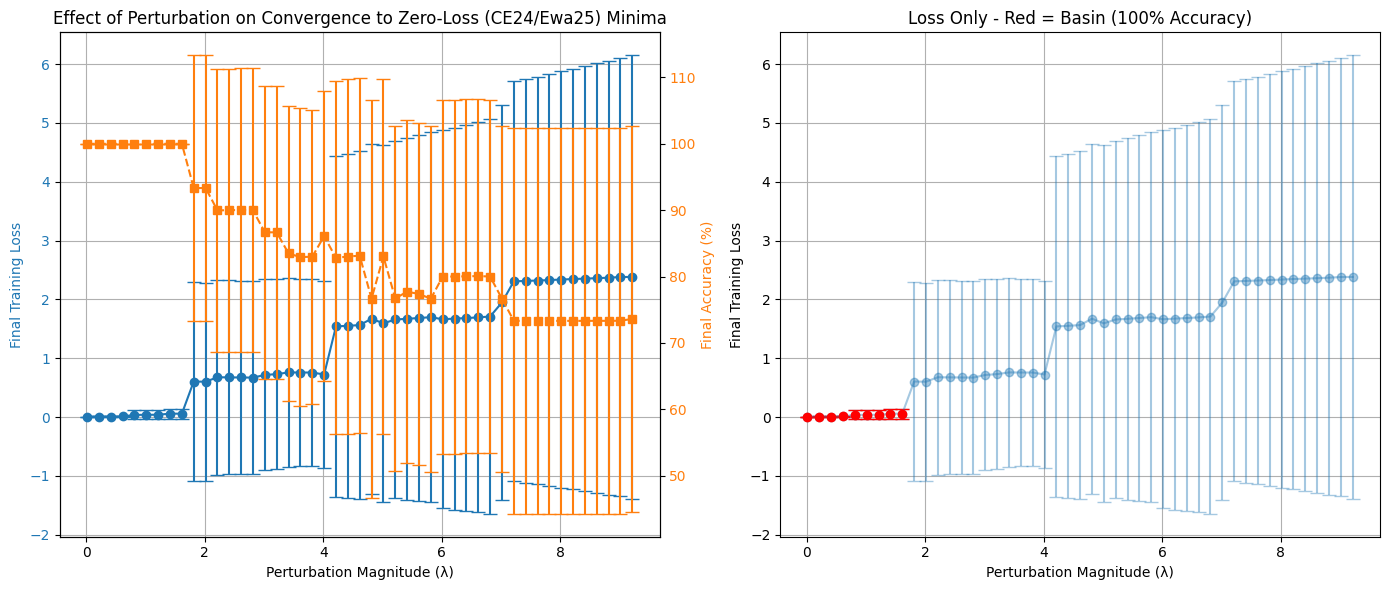


Running λ experiment for mask: [1, 1, 0]
λ=0.0150 | loss=0.02538±0.00010 | acc=100.00%±0.00%
λ=0.2150 | loss=0.02516±0.00123 | acc=100.00%±0.00%
λ=0.4150 | loss=0.02447±0.00255 | acc=100.00%±0.00%
λ=0.6150 | loss=0.02588±0.00769 | acc=100.00%±0.00%
λ=0.8150 | loss=0.02632±0.00946 | acc=100.00%±0.00%
λ=1.0150 | loss=0.02221±0.00828 | acc=100.00%±0.00%
λ=1.2150 | loss=0.02091±0.00830 | acc=100.00%±0.00%
λ=1.4150 | loss=0.02037±0.00863 | acc=100.00%±0.00%
λ=1.6150 | loss=0.02185±0.01167 | acc=100.00%±0.00%
λ=1.8150 | loss=0.02008±0.01297 | acc=100.00%±0.00%
λ=2.0150 | loss=0.02793±0.02660 | acc=100.00%±0.00%
λ=2.2150 | loss=0.02801±0.02444 | acc=100.00%±0.00%
λ=2.4150 | loss=0.03040±0.03714 | acc=100.00%±0.00%
λ=2.6150 | loss=0.11169±0.27700 | acc=96.67%±10.00%
λ=2.8150 | loss=0.11769±0.29300 | acc=96.67%±10.00%
λ=3.0150 | loss=0.11649±0.29104 | acc=96.67%±10.00%
λ=3.2150 | loss=0.12238±0.30273 | acc=96.67%±10.00%
λ=3.4150 | loss=0.13040±0.30727 | acc=96.67%±10.00%
λ=3.6150 | loss=0.1826

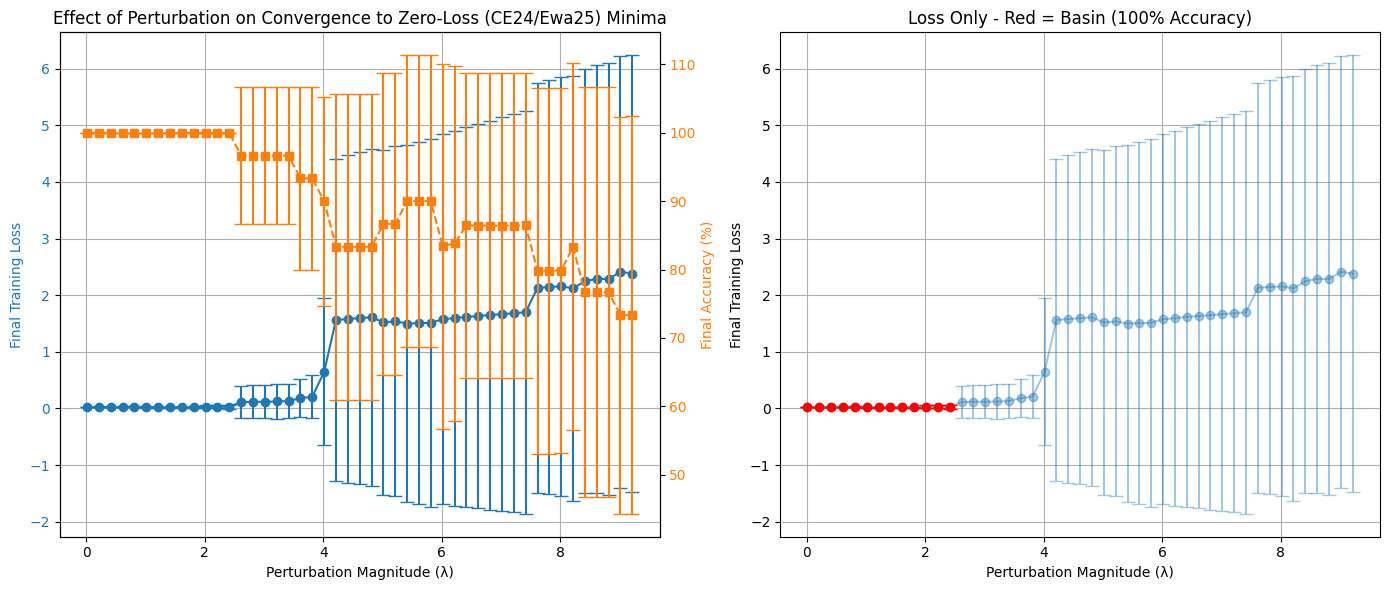


Running λ experiment for mask: [1, 1, 1]
λ=0.0150 | loss=0.14260±0.00052 | acc=100.00%±0.00%
λ=0.2150 | loss=0.13951±0.00656 | acc=100.00%±0.00%
λ=0.4150 | loss=0.13669±0.01295 | acc=100.00%±0.00%
λ=0.6150 | loss=0.13625±0.02018 | acc=100.00%±0.00%
λ=0.8150 | loss=0.14802±0.03202 | acc=100.00%±0.00%
λ=1.0150 | loss=0.24704±0.16673 | acc=93.43%±13.14%
λ=1.2150 | loss=0.25319±0.15207 | acc=96.70%±9.90%
λ=1.4150 | loss=0.28472±0.19001 | acc=90.01%±15.26%
λ=1.6150 | loss=0.29632±0.18643 | acc=90.01%±15.26%
λ=1.8150 | loss=0.42512±0.19991 | acc=83.35%±16.65%
λ=2.0150 | loss=0.45195±0.18378 | acc=83.29%±16.63%
λ=2.2150 | loss=0.50623±0.25629 | acc=79.95%±22.06%
λ=2.4150 | loss=0.51643±0.31950 | acc=79.91%±22.03%
λ=2.6150 | loss=0.48157±0.31051 | acc=80.30%±25.17%
λ=2.8150 | loss=0.48334±0.31362 | acc=83.74%±21.09%
λ=3.0150 | loss=0.47001±0.32965 | acc=86.38%±21.52%
λ=3.2150 | loss=0.48230±0.34679 | acc=85.63%±21.68%
λ=3.4150 | loss=0.59043±0.40199 | acc=77.63%±24.46%
λ=3.6150 | loss=0.58635

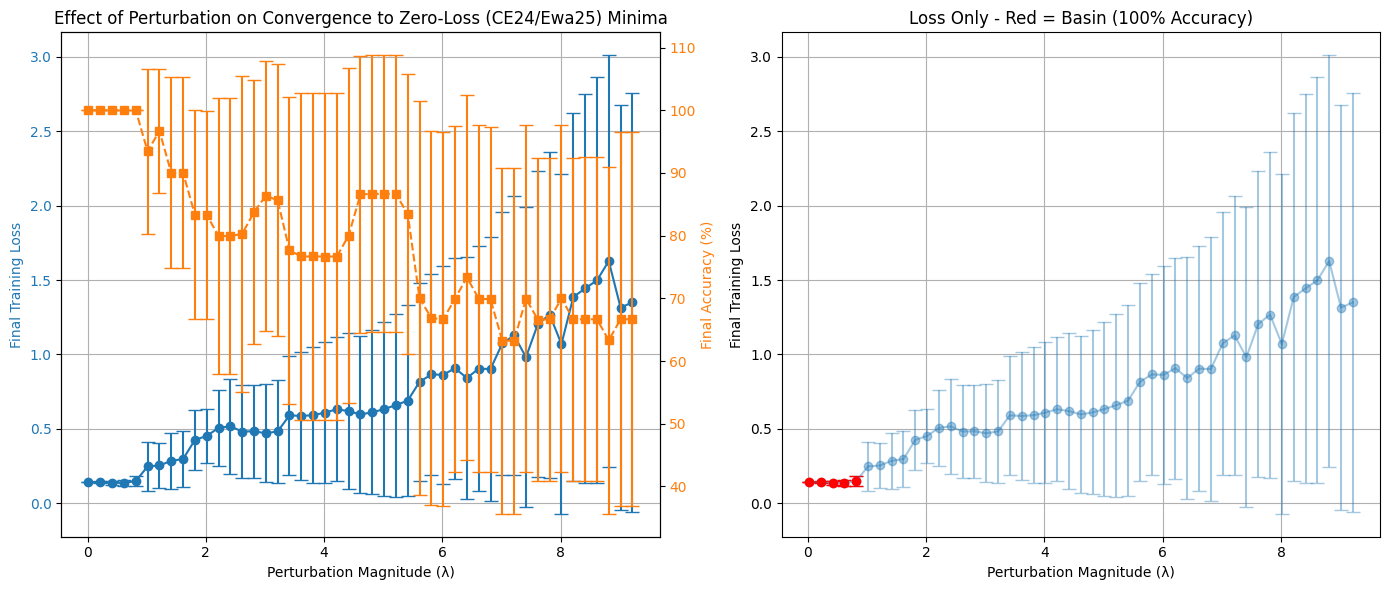

In [ ]:
# -----------------------------------------------------------------------------------------------------------
# Effect of λ Perturbations on Loss and Convergence (wrapped into one configurable method)
# -----------------------------------------------------------------------------------------------------------

def run_lambda_perturbation_experiment(Ws, bs, X_train, y_train, lambda_start=0.015, lambda_end=1.005, lambda_step=0.015, trials_per_lambda=10, epochs=1000, lr=0.01, dataset_info=None, verbose=False):

    def clone_model(Ws, bs):
        # Constructions from [CE24] and [Ewa25] used to find zero-cost global minima
        return deepcopy(Ws), deepcopy(bs)

    def add_perturbation(Ws, bs, lambda_val, seed=None):
        if seed is not None:
            np.random.seed(seed)
        perturbed_Ws, perturbed_bs = [], []

        # Add normalized Gaussian noise to each weight matrix
        for W in Ws:
            noise = np.random.randn(*W.shape)
            noise_norm = np.linalg.norm(noise)
            delta_W = (lambda_val / noise_norm) * noise  # scale noise to have norm = λ
            perturbed_Ws.append(W + delta_W)

        # Add normalized Gaussian noise to each bias vector
        for b in bs:
            noise = np.random.randn(*b.shape)
            noise_norm = np.linalg.norm(noise)
            delta_b = (lambda_val / noise_norm) * noise
            perturbed_bs.append(b + delta_b)

        return perturbed_Ws, perturbed_bs

    def train_network(perturbed_Ws, perturbed_bs, X_train, y_train, epochs=1000, lr=0.01, verbose=False):
        # "Use this perturbed vector to initialize, then see what SGD converges to"
        model = ExplicitReLU(deepcopy(perturbed_Ws), deepcopy(perturbed_bs))
        model.train()

        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()

        X_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_tensor = torch.tensor(y_train, dtype=torch.long)

        # Perform gradient descent to see if the network 'flows back' to zero-loss basin
        for epoch in range(epochs):
            optimizer.zero_grad()
            outputs = model(X_tensor)
            loss = criterion(outputs, y_tensor)
            loss.backward()
            optimizer.step()

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

        final_loss = loss.item()
        preds = outputs.argmax(dim=1)
        acc = (preds == y_tensor).float().mean().item()

        return final_loss, acc, model

    def run_experiment_across_lambdas(Ws, bs, X_train, y_train, lambda_vals, trials_per_lambda=10, epochs=1000, lr=0.01):
        # Smaller/larger norms (λ), multiple random perturbations, and average the final losses per lambda
        results = {}

        for lambda_val in lambda_vals:
            trial_losses, trial_accuracies = [], []
            Ws_list, bs_list = [], []

            for trial in range(trials_per_lambda):
                perturbed_Ws, perturbed_bs = add_perturbation(Ws, bs, lambda_val, seed=trial)
                loss, acc, trained_model = train_network(perturbed_Ws, perturbed_bs, X_train, y_train, epochs=epochs, lr=lr)
                trial_losses.append(loss)
                trial_accuracies.append(acc)

                Ws_final = [l.weight.detach().numpy().copy() for l in trained_model.layers]
                bs_final = [l.bias.detach().numpy().copy() for l in trained_model.layers]
                Ws_list.append(Ws_final)
                bs_list.append(bs_final)

            avg_loss = np.mean(trial_losses)
            std_loss = np.std(trial_losses)
            avg_acc = np.mean(trial_accuracies)
            std_acc = np.std(trial_accuracies)

            results[lambda_val] = {
                'losses': trial_losses,
                'accuracies': trial_accuracies,
                'Ws_list': Ws_list,
                'bs_list': bs_list,
                'dataset_info': dataset_info
            }

            print(f"λ={lambda_val:.4f} | loss={avg_loss:.5f}±{std_loss:.5f} | acc={avg_acc*100:.2f}%±{std_acc*100:.2f}%")

        return results

    def plot_loss_vs_lambda(results):
        import matplotlib.pyplot as plt

        lambdas = list(results.keys())
        mean_losses = [np.mean(results[λ]['losses']) for λ in lambdas]
        std_losses = [np.std(results[λ]['losses']) for λ in lambdas]
        mean_accs = [np.mean(results[λ]['accuracies']) for λ in lambdas]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 2]})

        # ----- Left Plot (Standard Loss & Accuracy Plot) -----
        ax1.errorbar(lambdas, mean_losses, yerr=std_losses, fmt='o-', capsize=5, color='tab:blue')
        ax1.set_xlabel("Perturbation Magnitude (λ)")
        ax1.set_ylabel("Final Training Loss", color='tab:blue')
        ax1.tick_params(axis='y', labelcolor='tab:blue')
        ax1.grid(True)

        ax3 = ax1.twinx()
        mean_accs_percent = [acc * 100 for acc in mean_accs]
        std_accs_percent = [np.std(results[λ]['accuracies']) * 100 for λ in lambdas]
        ax3.errorbar(lambdas, mean_accs_percent, yerr=std_accs_percent, fmt='s--', capsize=5, color='tab:orange')
        ax3.set_ylabel("Final Accuracy (%)", color='tab:orange')
        ax3.tick_params(axis='y', labelcolor='tab:orange')

        ax1.set_title("Effect of Perturbation on Convergence to Zero-Loss (CE24/Ewa25) Minima")

        # ----- Right Plot (Loss Only + Connected Line + Red Highlights for 100% Acc) -----
        ax2.errorbar(lambdas, mean_losses, yerr=std_losses, fmt='o-', capsize=5, color='tab:blue', alpha=0.4)

        for i, λ in enumerate(lambdas):
            if mean_accs[i] == 1.0:
                ax2.errorbar(λ, mean_losses[i], yerr=std_losses[i], fmt='o', capsize=5, color='red')

        ax2.set_xlabel("Perturbation Magnitude (λ)")
        ax2.set_ylabel("Final Training Loss")
        ax2.grid(True)
        ax2.set_title("Loss Only - Red = Basin (100% Accuracy)")
        plt.tight_layout()
        plt.show()

    # ---- Run the λ sweep ----
    lambda_values = list(np.arange(lambda_start, lambda_end + lambda_step, lambda_step))
    results = run_experiment_across_lambdas(Ws, bs, X_train, y_train, lambda_values,
                                            trials_per_lambda=trials_per_lambda, epochs=epochs, lr=lr, )
    plot_loss_vs_lambda(results)
    return results

# pick a few masks (symmetry → don’t need all)
selected_masks = [
    [1,1,1],   # global
    [1,1,0],   # 1 class off
    [1,0,0],   # 2 classes off
]

all_results = {}

for m in minima:
    if m["mask"] in selected_masks:
        mask_tuple = tuple(m["mask"])
        print("\nRunning λ experiment for mask:", m["mask"])

        results_lambda = run_lambda_perturbation_experiment(
            m["Ws"], m["bs"], X_train, y_train,
            lambda_start=0.015,
            lambda_end=9.0225,
            lambda_step=0.2,
            trials_per_lambda=10,
            epochs=500,
            lr=0.01,
            dataset_info=str(m["mask"])
        )

        all_results[mask_tuple] = results_lambda


## **Step 5b – Visualizing $\lambda$ Perturbations on Suboptimal Minima with Truncation Maps**

Available masks:
(1, 0, 0)
(1, 1, 0)
(1, 1, 1)
Choose mask (e.g. 1 1 0): 1 1 1

=== Dataset Info ===
[1, 1, 1]

Enter λ value to visualize: 0
Nearest computed λ → 0.0150
Average Loss = 0.14260 | Average Accuracy = 100.00%
Select trial index (0–9): 1
Trial 1: Loss=0.14191, Acc=100.00%


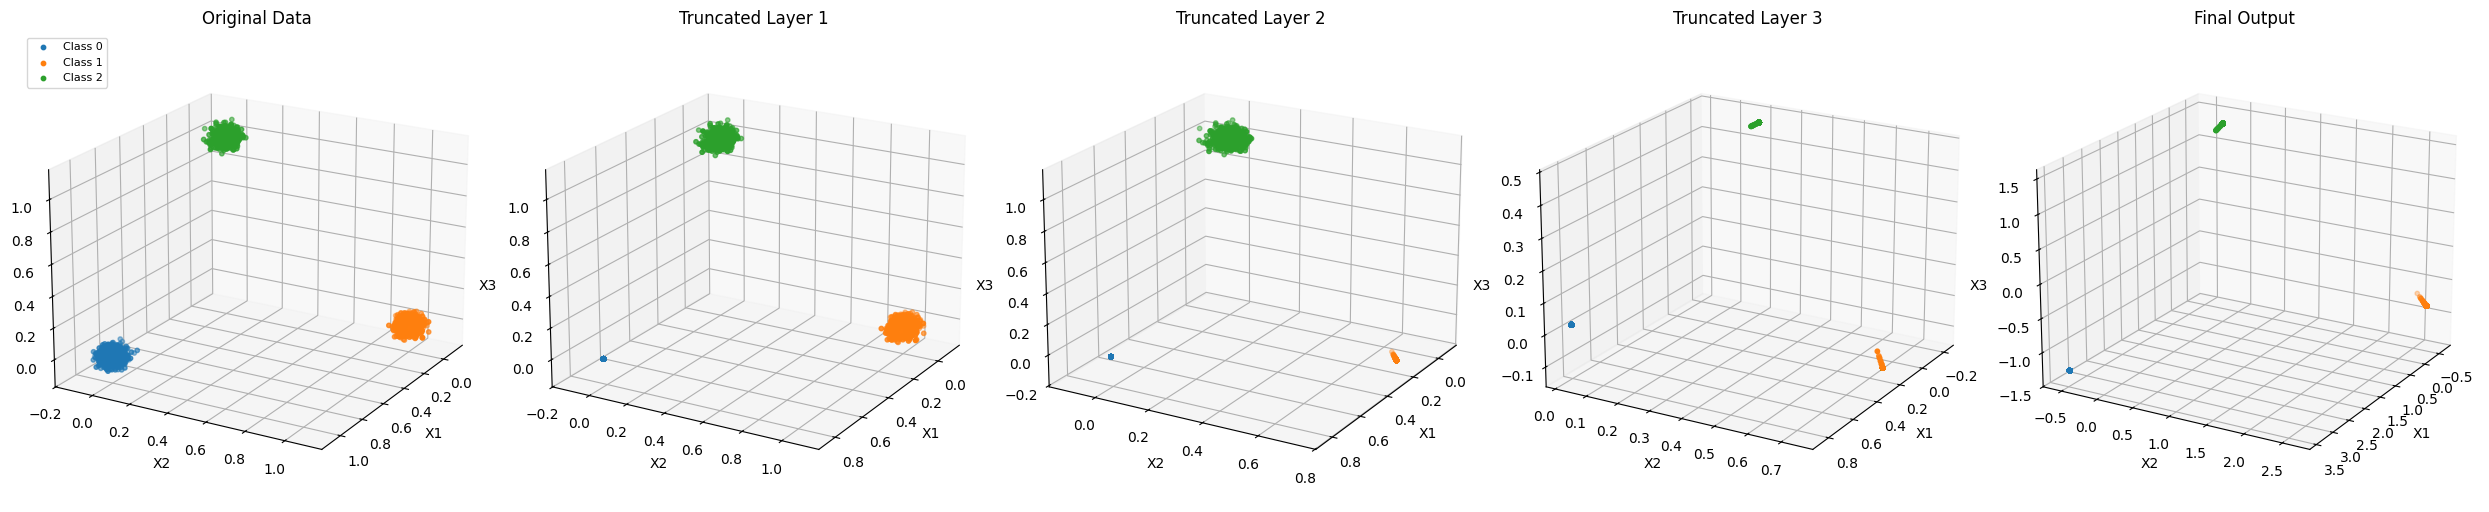

In [ ]:
print("Available masks:")
for k in all_results.keys():
    print(k)

mask_input = tuple(map(int, input("Choose mask (e.g. 1 1 0): ").split()))

if mask_input not in all_results:
    print("Mask not found.")
else:
    results_lambda = all_results[mask_input]

print("\n=== Dataset Info ===")
print(results_lambda[next(iter(results_lambda))]['dataset_info'])  # grabs from first λ entry
print("====================\n")

lambda_input = float(input("Enter λ value to visualize: "))
lambda_sel = min(results_lambda.keys(), key=lambda l: abs(l - lambda_input))
print(f"Nearest computed λ → {lambda_sel:.4f}")

losses = results_lambda[lambda_sel]['losses']
accuracies = results_lambda[lambda_sel]['accuracies']
avg_loss = np.mean(losses)
avg_acc = np.mean(accuracies)
print(f"Average Loss = {avg_loss:.5f} | Average Accuracy = {avg_acc*100:.2f}%")

trial_idx = int(input(f"Select trial index (0–{len(losses)-1}): "))

# Use stored trained Ws and bs directly
Ws_sel = results_lambda[lambda_sel]['Ws_list'][trial_idx]
bs_sel = results_lambda[lambda_sel]['bs_list'][trial_idx]

print(f"Trial {trial_idx}: Loss={losses[trial_idx]:.5f}, Acc={accuracies[trial_idx]*100:.2f}%")
plot_truncated(Ws_sel, bs_sel, X_train, y_train)

## **Step No. 6a - Creating $\alpha$ and $\beta$ Perturbations on Suboptimal Minima to Visualize 3D Loss Landscape & Accuracy Basin**



-----------------------------------------------------------------
Running α,β experiment for mask: [1, 0, 0]
-----------------------------------------------------------------

(α=-5.000, β=-5.000) | loss=96.71256 | acc=33.33%
(α=-5.000, β=-4.474) | loss=91.34530 | acc=33.33%
(α=-5.000, β=-3.947) | loss=86.13101 | acc=33.33%
(α=-5.000, β=-3.421) | loss=81.06803 | acc=33.33%
(α=-5.000, β=-2.895) | loss=72.95257 | acc=33.33%
(α=-5.000, β=-2.368) | loss=62.28805 | acc=33.33%
(α=-5.000, β=-1.842) | loss=52.69800 | acc=33.33%
(α=-5.000, β=-1.316) | loss=44.15577 | acc=33.33%
(α=-5.000, β=-0.789) | loss=36.63535 | acc=33.33%
(α=-5.000, β=-0.263) | loss=30.11150 | acc=33.33%
(α=-5.000, β=0.263) | loss=24.56033 | acc=33.33%
(α=-5.000, β=0.789) | loss=19.96183 | acc=33.33%
(α=-5.000, β=1.316) | loss=16.50987 | acc=45.96%
(α=-5.000, β=1.842) | loss=16.28907 | acc=66.67%
(α=-5.000, β=2.368) | loss=17.00301 | acc=66.67%
(α=-5.000, β=2.895) | loss=19.98327 | acc=66.67%
(α=-5.000, β=3.421) | loss=29.

-----------------------------------------------------------------
Running α,β experiment for mask: [1, 1, 0]
-----------------------------------------------------------------

(α=-5.000, β=-5.000) | loss=26.71191 | acc=33.33%
(α=-5.000, β=-4.474) | loss=25.36781 | acc=33.33%
(α=-5.000, β=-3.947) | loss=24.17518 | acc=33.33%
(α=-5.000, β=-3.421) | loss=23.27569 | acc=33.33%
(α=-5.000, β=-2.895) | loss=22.36021 | acc=33.33%
(α=-5.000, β=-2.368) | loss=21.31807 | acc=33.33%
(α=-5.000, β=-1.842) | loss=20.14187 | acc=33.33%
(α=-5.000, β=-1.316) | loss=18.82749 | acc=33.33%
(α=-5.000, β=-0.789) | loss=17.37159 | acc=33.33%
(α=-5.000, β=-0.263) | loss=15.77139 | acc=33.33%
(α=-5.000, β=0.263) | loss=14.02464 | acc=33.33%
(α=-5.000, β=0.789) | loss=11.93824 | acc=33.33%
(α=-5.000, β=1.316) | loss=9.32665 | acc=33.33%
(α=-5.000, β=1.842) | loss=6.68942 | acc=33.33%
(α=-5.000, β=2.368) | loss=4.75856 | acc=33.33%
(α=-5.000, β=2.895) | loss=4.93114 | acc=3.38%
(α=-5.000, β=3.421) | loss=8.04588 

-----------------------------------------------------------------
Running α,β experiment for mask: [1, 1, 1]
-----------------------------------------------------------------

(α=-5.000, β=-5.000) | loss=0.95409 | acc=61.42%
(α=-5.000, β=-4.474) | loss=0.93556 | acc=36.46%
(α=-5.000, β=-3.947) | loss=1.32295 | acc=60.17%
(α=-5.000, β=-3.421) | loss=1.75058 | acc=65.42%
(α=-5.000, β=-2.895) | loss=1.99006 | acc=66.58%
(α=-5.000, β=-2.368) | loss=2.08226 | acc=66.67%
(α=-5.000, β=-1.842) | loss=2.11632 | acc=66.67%
(α=-5.000, β=-1.316) | loss=2.11670 | acc=51.96%
(α=-5.000, β=-0.789) | loss=2.09851 | acc=33.71%
(α=-5.000, β=-0.263) | loss=2.06881 | acc=33.33%
(α=-5.000, β=0.263) | loss=2.02709 | acc=33.33%
(α=-5.000, β=0.789) | loss=1.97152 | acc=33.33%
(α=-5.000, β=1.316) | loss=1.79164 | acc=0.00%
(α=-5.000, β=1.842) | loss=1.56012 | acc=0.25%
(α=-5.000, β=2.368) | loss=1.35733 | acc=18.96%
(α=-5.000, β=2.895) | loss=1.22274 | acc=55.21%
(α=-5.000, β=3.421) | loss=1.27702 | acc=33.29%


-----------------------------------------------------------------



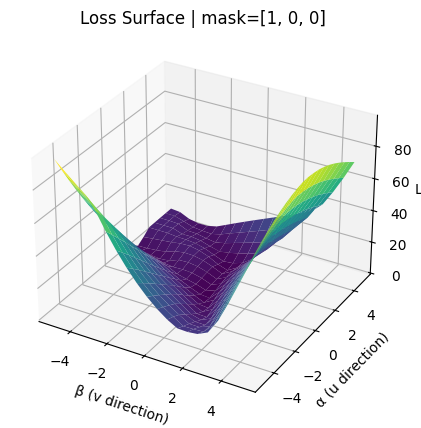

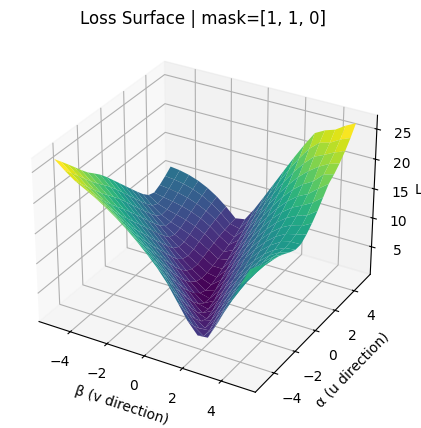

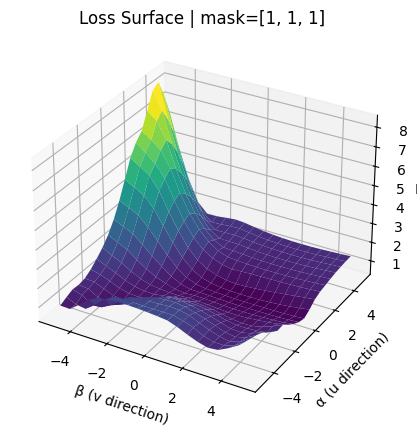

In [ ]:
def two_d_perturbation_experiment(Ws, bs, X_train, y_train,
                                  alpha_min, alpha_max,
                                  beta_min, beta_max,
                                  num_points,
                                  dataset_info):

    # -----------------------------------------------------------------------------------------------------------
    # Step 5 – Effect of 2D Perturbations (α·u + β·v) on Loss Landscape and Convergence
    # -----------------------------------------------------------------------------------------------------------

    # λ = α·u + β·v is a 2D perturbation vector in parameter space
    # since u and v are orthonormal -> ||u|| = ||v|| = 1 and u ⊥ v
    # the perturbation norm is: ||λ|| = root(α² + β²)
    # so iterating α, β over a grid implicitly varies ||λ||

    def flatten_params(Ws, bs):
        return np.concatenate([W.flatten() for W in Ws] + [b.flatten() for b in bs])

    def unflatten_params(flat, Ws_shapes, bs_shapes):
        Ws, bs = [], []
        idx = 0
        for shape in Ws_shapes:
            size = np.prod(shape)
            Ws.append(flat[idx:idx+size].reshape(shape))
            idx += size
        for shape in bs_shapes:
            size = np.prod(shape)
            bs.append(flat[idx:idx+size].reshape(shape))
            idx += size
        return Ws, bs

    # Initialize θ and construct two orthonormal directions u, v
    def init_uv(Ws, bs):
        theta = flatten_params(Ws, bs) # zero-loss construction
        dim = theta.shape[0]
        u = np.random.randn(dim) # random direction u
        u = u / np.linalg.norm(u)
        v_raw = np.random.randn(dim) # make v orthogonal to u
        v = v_raw - np.dot(v_raw, u) * u
        v = v / np.linalg.norm(v)
        return theta, u, v

    # Apply 2D perturbation along α·u + β·v
    def apply_2d_perturbation(theta, u, v, alpha, beta, Ws_shapes, bs_shapes):
        perturbed_theta = theta + alpha * u + beta * v
        return unflatten_params(perturbed_theta, Ws_shapes, bs_shapes)

    # # Train model initialized with (α, β) perturbation
    # def train_network(perturbed_Ws, perturbed_bs, X_train, y_train, epochs=1000, lr=0.01, verbose=False):
    #     model = ExplicitReLU(deepcopy(perturbed_Ws), deepcopy(perturbed_bs))
    #     model.train()
    #     optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    #     criterion = nn.CrossEntropyLoss()

    #     X_tensor = torch.tensor(X_train, dtype=torch.float32)
    #     y_tensor = torch.tensor(y_train, dtype=torch.long)

    #     for epoch in range(epochs):
    #         optimizer.zero_grad()
    #         outputs = model(X_tensor)
    #         loss = criterion(outputs, y_tensor)
    #         loss.backward()
    #         optimizer.step()

    #     final_loss = loss.item()
    #     preds = outputs.argmax(dim=1)
    #     acc = (preds == y_tensor).float().mean().item()
    #     return final_loss, acc, model

    # Instead of training, we directly compute loss/accuracy at this point
    def evaluate_network(perturbed_Ws, perturbed_bs, X_train, y_train):
        model = ExplicitReLU(deepcopy(perturbed_Ws), deepcopy(perturbed_bs))
        model.eval()

        X_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_tensor = torch.tensor(y_train, dtype=torch.long)

        with torch.no_grad():
            outputs = model(X_tensor)
            criterion = nn.CrossEntropyLoss()
            loss = criterion(outputs, y_tensor).item()
            preds = outputs.argmax(dim=1)
            acc = (preds == y_tensor).float().mean().item()

        return loss, acc
    # -----------------------------

    def run_2d_experiment(Ws, bs, X_train, y_train, alpha_vals, beta_vals):
        theta, u, v = init_uv(Ws, bs)
        Ws_shapes = [W.shape for W in Ws]
        bs_shapes = [b.shape for b in bs]

        results = {}
        for alpha in alpha_vals:
            for beta in beta_vals:
                if alpha == 0 and beta == 0:
                    continue

                perturbed_Ws, perturbed_bs = apply_2d_perturbation(theta, u, v, alpha, beta, Ws_shapes, bs_shapes)
                #loss, acc, model = train_network(perturbed_Ws, perturbed_bs, X_train, y_train, epochs=epochs, lr=lr)
                loss, acc = evaluate_network(perturbed_Ws, perturbed_bs, X_train, y_train)

                results[(alpha, beta)] = {
                    'loss': loss,
                    'acc': acc,
                    'Ws': perturbed_Ws,
                    'bs': perturbed_bs,
                    'dataset_info': dataset_info
                }

                print(f"(α={alpha:.3f}, β={beta:.3f}) | loss={loss:.5f} | acc={acc*100:.2f}%")

        return results

    def save_matplotlib_surface_as_image(results, alpha_vals, beta_vals, key='loss', dataset_info=None):
        Z = np.array([[results[(a,b)][key] for b in beta_vals] for a in alpha_vals])
        A, B = np.meshgrid(beta_vals, alpha_vals)

        fig = plt.figure(figsize=(6, 5))
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(A, B, Z, cmap='viridis', edgecolor='none')
        ax.set_xlabel('β (v direction)')
        ax.set_ylabel('α (u direction)')
        ax.set_zlabel(f'{key.capitalize()}')

        title_str = f'{key.capitalize()} Surface'
        if dataset_info is not None:
            title_str += f' | mask={dataset_info}'
        ax.set_title(title_str)

        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        buf.seek(0)
        img = Image.open(buf)
        return img

    def plot_combined_surface_and_basin(results, alpha_vals, beta_vals, dataset_info=None):

        img = save_matplotlib_surface_as_image(results, alpha_vals, beta_vals, dataset_info=dataset_info)
        Z = np.array([[results[(a, b)]['loss'] for b in beta_vals] for a in alpha_vals])
        ACC = np.array([[results[(a, b)]['acc'] for b in beta_vals] for a in alpha_vals])

        basin_mask = (ACC == 1.0)
        threshold = Z[basin_mask].max() if np.any(basin_mask) else Z.min()
        surface_mask = np.where(
            (ACC == 1.0) & (Z <= threshold),
            0.0,
            (Z - Z.min()) / (Z.max() - Z.min()) * 0.9 + 0.1
        )

        custom_colorscale = [
            [0.0, 'red'], [0.001, 'red'],
            [0.1, 'rgb(68,1,84)'],
            [0.5, 'rgb(59,82,139)'],
            [0.75, 'rgb(33,145,140)'],
            [1.0, 'rgb(253,231,37)']
        ]

        fig = go.Figure(data=[go.Surface(
            z=Z, x=beta_vals, y=alpha_vals,
            surfacecolor=surface_mask,
            colorscale=custom_colorscale,
            showscale=True,
            cmin=0, cmax=1,
            colorbar=dict(
                title='Loss Category',
                tickvals=[0, 0.5, 1],
                ticktext=['Basin (100%)', 'Mid', 'High']
            )
        )])

        fig.update_layout(
            title="Loss Surface with 100% Accuracy Basin Highlighted",
            scene=dict(
                xaxis_title="β (v direction)",
                yaxis_title="α (u direction)",
                zaxis_title="Loss"
            ),
            height=600,
            width=800
        )

        fig.show()

    # run the 2D perturbation experiment
    alpha_vals = np.linspace(alpha_min, alpha_max, num_points)
    beta_vals  = np.linspace(beta_min, beta_max, num_points)
    results = run_2d_experiment(Ws, bs, X_train, y_train, alpha_vals, beta_vals)
    print("-----------------------------------------------------------------\n")
    plot_combined_surface_and_basin(results, alpha_vals, beta_vals, dataset_info)

    if i == len(minima) - 1:
      print("-----------------------------------------------------------------\n")
    return results, alpha_vals, beta_vals

selected_masks = [
    [1,1,1],
    [1,1,0],
    [1,0,0],
]

all_results_2d = {}

for i, m in enumerate(minima):
    if m["mask"] in selected_masks:
        mask_tuple = tuple(m["mask"])
        print("-----------------------------------------------------------------")
        print("Running α,β experiment for mask:", m["mask"])
        print("-----------------------------------------------------------------\n")

        results_2d, alpha_vals, beta_vals = two_d_perturbation_experiment(
            m["Ws"], m["bs"], X_train, y_train,
            alpha_min=-5.0, alpha_max=5.0,
            beta_min=-5.0, beta_max=5.0,
            num_points=20,
            dataset_info=str(m["mask"])
        )

        all_results_2d[mask_tuple] = results_2d

## **Step 6b – Visualizing $\alpha$ and $\beta$ Perturbations on Suboptimal Minima with Truncation Maps**

Available masks:
(1, 0, 0)
(1, 1, 0)
(1, 1, 1)
Choose mask (e.g. 1 1 0): 1 1 1

=== Dataset Info ===
[1, 1, 1]

Enter α: 0
Enter β: 0
Nearest computed pair → α=0.263, β=0.263
Loss=0.5032, Acc=100.0%


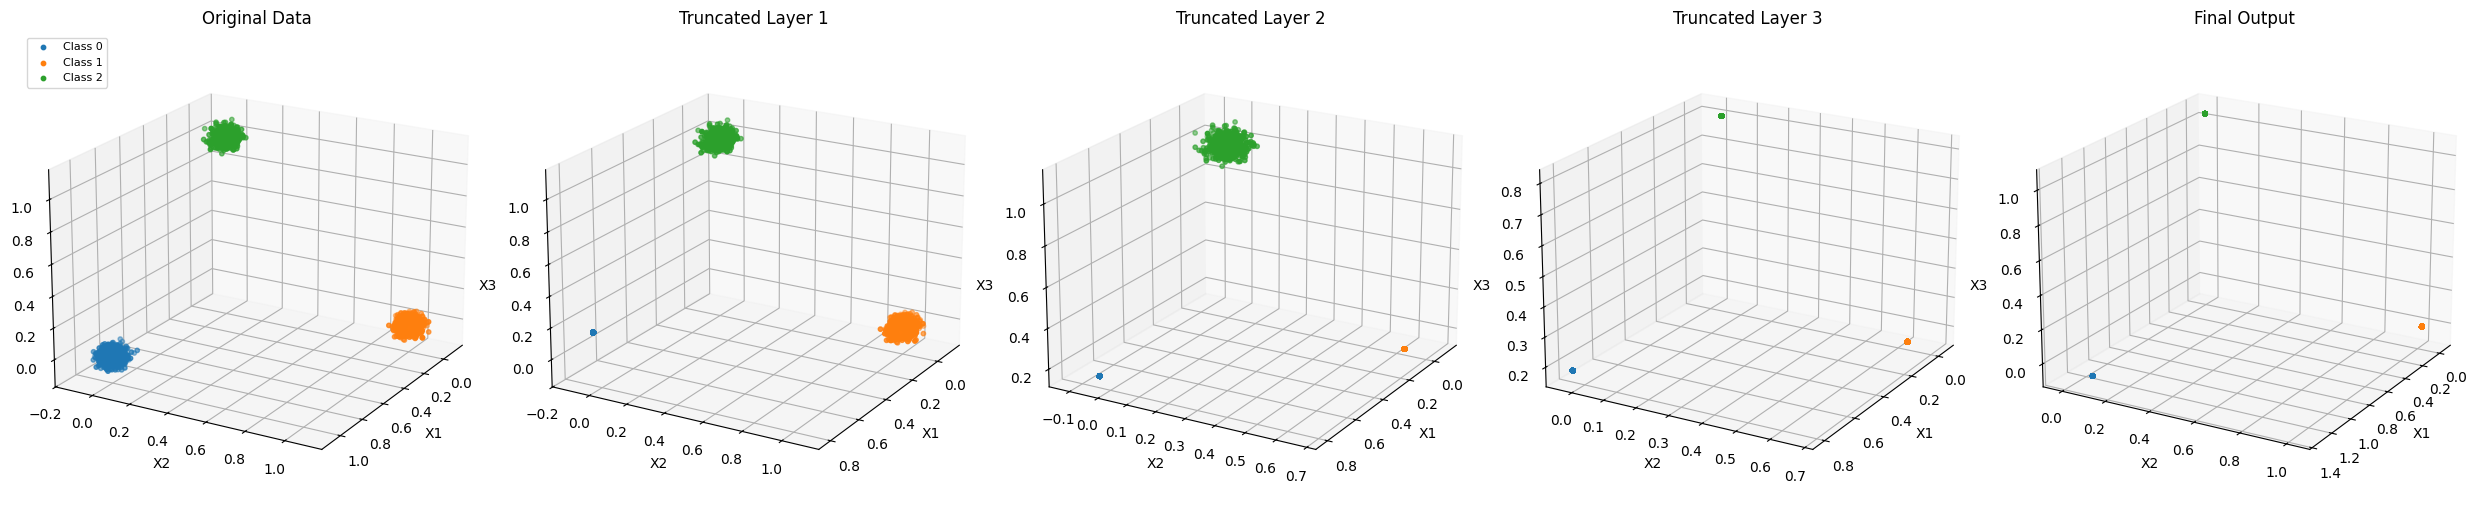

In [ ]:
print("Available masks:")
for k in all_results_2d.keys():
    print(k)

mask_input = tuple(map(int, input("Choose mask (e.g. 1 1 0): ").split()))
results_a_b = all_results_2d[mask_input]

print("\n=== Dataset Info ===")
print(results_a_b[next(iter(results_a_b))]['dataset_info'])
print("====================\n")

alpha = float(input("Enter α: "))
beta  = float(input("Enter β: "))

alpha_sel = min(alpha_vals, key=lambda a: abs(a - alpha))
beta_sel  = min(beta_vals, key=lambda b: abs(b - beta))

print(f"Nearest computed pair → α={alpha_sel:.3f}, β={beta_sel:.3f}")

Ws_sel = results_a_b[(alpha_sel, beta_sel)]['Ws']
bs_sel = results_a_b[(alpha_sel, beta_sel)]['bs']

print(f"Loss={results_a_b[(alpha_sel,beta_sel)]['loss']:.4f}, "
      f"Acc={results_a_b[(alpha_sel,beta_sel)]['acc']*100:.1f}%")

plot_truncated(Ws_sel, bs_sel, X_train, y_train)
